# Analysez les ventes d'une librairie

L’entreprise Lapage était originellement une librairie physique avec plusieurs points de vente. Mais devant le succès de certains de ses produits et l’engouement de ses clients, elle a décidé depuis 2 ans d’ouvrir un site de vente en ligne. 

Cette analyse va être découpée en deux parties :
- Une analyse des différents indicateurs de vente, qui a été demandée dans le brief (tu le trouveras en pièce jointe),
- Une analyse plus ciblée sur les clients : l’objectif est de comprendre le comportement de nos clients en ligne, pour pouvoir ensuite comparer avec la connaissance acquise via nos librairies physiques. 

## Partie 1 - Chargement des données

### A - Chargement des librairies 

In [1]:
# Importation des librairies nécessaires à l'analyse

import pandas as pd               # Pour la manipulation de données
import numpy as np                # Pour les calculs numériques
import matplotlib.pyplot as plt   # Pour la visualisation
import seaborn as sns             # Pour les graphiques statistiques
import warnings                   # Pour gérer les warnings

### B - Chargement des fichiers

In [2]:
# Configuration des options d'affichage

pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes
pd.set_option('display.max_rows', None)     # Afficher toutes les lignes
pd.set_option('display.width', None)        # Configuration pour la largeur d'affichage
warnings.filterwarnings('ignore')           # Ignorer les warnings pour plus de clarté
sns.set(style="whitegrid")                  # Style des graphiques

In [3]:
# Chargement des fichiers CSV dans des DataFrames

customers_df = pd.read_csv("customers.csv", sep=";")
products_df = pd.read_csv("products.csv", sep=";")
transactions_df = pd.read_csv("transactions.csv", sep=";")

In [4]:
# Affichage d'un aperçu de chaque jeu de données

print("✅ Customers.csv :")
display(customers_df.head())

print("✅ Products.csv :")
display(products_df.head())

print("✅ Transactions.csv :")
display(transactions_df.head())

✅ Customers.csv :


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


✅ Products.csv :


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


✅ Transactions.csv :


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


## Partie 2 - Analyses exploratoires / Nettoyages

### A - Fichier Customers

In [5]:
# Aperçu général du fichier customers
print("📊 Informations générales :")
customers_df.info()

print("\n📏 Dimensions du jeu de données :", customers_df.shape)
print("\n🔍 Aperçu des premières lignes :")
display(customers_df.head())

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB

📏 Dimensions du jeu de données : (8621, 3)

🔍 Aperçu des premières lignes :


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [6]:
# Vérification des valeurs manquantes
print("🕳️ Valeurs manquantes par colonne :")
print(customers_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
client_id    0
sex          0
birth        0
dtype: int64


Aucune valeur manquante dans ce fichier

In [7]:
# Vérification des doublons complets (lignes identiques)
print("📋 Nombre de lignes dupliquées :", customers_df.duplicated().sum())

# Vérification de l’unicité des identifiants clients
print("🆔 Nombre d'IDs clients uniques :", customers_df['client_id'].nunique())
if customers_df['client_id'].nunique() == customers_df.shape[0]:
    print("✅ Tous les client_id sont uniques.")
else:
    print("⚠️ Attention : certains client_id sont dupliqués.")

📋 Nombre de lignes dupliquées : 0
🆔 Nombre d'IDs clients uniques : 8621
✅ Tous les client_id sont uniques.


Pas de doublon dans la colonne client_id, qui servira de clef de jointure

In [8]:
# Valeurs uniques de la colonne sex
print("🚻 Répartition des sexes :")
print(customers_df['sex'].value_counts(dropna=False))

🚻 Répartition des sexes :
sex
f    4490
m    4131
Name: count, dtype: int64


In [9]:
# Vérification des années de naissance
print("📅 Valeurs uniques dans 'birth' (année de naissance) :")
print(customers_df['birth'].sort_values().unique())

# Renommage de la colonne pour plus de clarté
customers_df.rename(columns={'birth': 'birth_year'}, inplace=True)

# Détection d'années aberrantes
print("\n⚠️ Années de naissance suspectes (<1900 ou >2020) :")
print(customers_df[(customers_df['birth_year'] < 1900) | (customers_df['birth_year'] > 2020)])
print("Année de naissance la plus basse :", int(customers_df['birth_year'].min()))
print("Année de naissance la plus haute :", int(customers_df['birth_year'].max()))

📅 Valeurs uniques dans 'birth' (année de naissance) :
[1929 1930 1931 1932 1933 1934 1935 1936 1937 1938 1939 1940 1941 1942
 1943 1944 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956
 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004]

⚠️ Années de naissance suspectes (<1900 ou >2020) :
Empty DataFrame
Columns: [client_id, sex, birth_year]
Index: []
Année de naissance la plus basse : 1929
Année de naissance la plus haute : 2004


Toutes les dates de naissances sont comprises entre 1929 et 2004, donc pas d'année de naissance aberrante

### B - Fichier Products

In [10]:
# Informations générales sur le fichier products
print("📊 Informations générales :")
products_df.info()

print("\n📏 Dimensions du jeu de données :", products_df.shape)
print("\n🔍 Aperçu des premières lignes :")
display(products_df.head())

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB

📏 Dimensions du jeu de données : (3286, 3)

🔍 Aperçu des premières lignes :


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [11]:
# Vérification des valeurs manquantes
print("🕳️ Valeurs manquantes par colonne :")
print(products_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
id_prod    0
price      0
categ      0
dtype: int64


Aucune valeur manquante dans ce fichier

In [12]:
# Vérification des doublons complets
print("📋 Nombre de lignes dupliquées :", products_df.duplicated().sum())

# Vérification de l’unicité des identifiants produit
print("🔑 Nombre d'identifiants produit uniques :", products_df['id_prod'].nunique())
if products_df['id_prod'].nunique() == products_df.shape[0]:
    print("✅ Tous les id_prod sont uniques.")
else:
    print("⚠️ Attention : certains id_prod sont dupliqués.")

📋 Nombre de lignes dupliquées : 0
🔑 Nombre d'identifiants produit uniques : 3286
✅ Tous les id_prod sont uniques.


Pas de doublon dans la colonne id_prod, qui servira de clef de jointure

In [13]:
# Vérification du type et des statistiques sur les prix
print("💰 Statistiques sur les prix des produits :")
print(products_df['price'].describe())

# Détection de prix négatifs ou aberrants
print("\n⚠️ Produits avec un prix <= 0 :")
display(products_df[products_df['price'] <= 0])

💰 Statistiques sur les prix des produits :
count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64

⚠️ Produits avec un prix <= 0 :


,id_prod,price,categ


Pas de prix négatifs, donc on supprose pas de valeur aberrante

In [14]:
# Valeurs uniques de la colonne categ
print("🏷️ Catégories de produits disponibles :")
print(products_df['categ'].value_counts(dropna=False))

# Convertir les catégories en type "category" pour optimiser la mémoire
products_df['categ'] = products_df['categ'].astype('category')

🏷️ Catégories de produits disponibles :
categ
0    2308
1     739
2     239
Name: count, dtype: int64


### C - Fichier Transactions

In [15]:
# Informations générales sur le fichier transactions
print("📊 Informations générales :")
transactions_df.info()

print("\n📏 Dimensions du jeu de données :", transactions_df.shape)
print("\n🔍 Aperçu des premières lignes :")
display(transactions_df.head())

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB

📏 Dimensions du jeu de données : (1048575, 4)

🔍 Aperçu des premières lignes :


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [16]:
# Vérification des valeurs manquantes
print("🕳️ Valeurs manquantes par colonne :")
print(transactions_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64


In [17]:
# Vérification des lignes dupliquées
print("📋 Nombre de lignes dupliquées :", transactions_df.duplicated().sum())

📋 Nombre de lignes dupliquées : 361040


1 048 575 correspond à 2^20, soit le nombre maximal de ligne dans une feuille excel.
Cela signifie très probablement que :
 - Mon fichier .csv a été enregistré depuis Excel ou un tableur qui a ajouté des lignes vides jusqu'à la limite.
 - Ces lignes sont présentes physiquement dans le fichier, mais elles sont vides à part les séparateurs ;.

De plus, nous avons bien 361 040 lignes qui semblent entièrement vides.
1 048 757 - 361 040 = 687 534. Nous devrions donc avoir 687 534 lignes.

Supprimons donc ces lignes vides qui sont inutiles.

In [18]:
# Suppression manuelle par sécurité (lignes totalement vides)
transactions_df.dropna(how='all', inplace=True)

# Re-vérification
print("📏 Dimensions après nettoyage :", transactions_df.shape)

📏 Dimensions après nettoyage : (687534, 4)


In [19]:
# Vérification du type de la colonne date
print("📅 Type initial de 'date' :", transactions_df['date'].dtype)

# Statistiques de dates
print("\n📈 Plage de dates des transactions :")
print("Date la plus ancienne :", transactions_df['date'].min())
print("Date la plus récente :", transactions_df['date'].max())

📅 Type initial de 'date' : object

📈 Plage de dates des transactions :
Date la plus ancienne : 2021-03-01 00:01:07.843138
Date la plus récente : 2023-02-28 23:58:30.792755


In [20]:
# Transactions avec client_id ou id_prod manquant
print("⚠️ Transactions avec client_id manquant :")
display(transactions_df[transactions_df['client_id'].isnull()])

print("\n⚠️ Transactions avec id_prod manquant :")
display(transactions_df[transactions_df['id_prod'].isnull()])

⚠️ Transactions avec client_id manquant :


,id_prod,date,session_id,client_id



⚠️ Transactions avec id_prod manquant :


,id_prod,date,session_id,client_id


Pas de transaction suspecte détectée.

## Partie 3 - Jointures

### A - Jointure entre customers_df et transactions_df

In [21]:
# Analyse des clés : client_id

# Dimensions des datasets
print("📏 Nombre de lignes dans customers_df :", customers_df.shape[0])
print("📏 Nombre de lignes dans transactions_df :", transactions_df.shape[0])

# Nombre d'identifiants uniques
print("🔑 client_id uniques dans customers_df :", customers_df['client_id'].nunique())
print("🔑 client_id uniques dans transactions_df :", transactions_df['client_id'].nunique())

# Valeurs présentes dans transactions mais pas dans customers
clients_not_in_customers = transactions_df[~transactions_df['client_id'].isin(customers_df['client_id'])]
print("⚠️ Nombre de client_id présents dans transactions_df mais absents de customers_df :", clients_not_in_customers['client_id'].nunique())

# Vérification des formats
print("📋 Type client_id - customers_df :", customers_df['client_id'].dtype)
print("📋 Type client_id - transactions_df :", transactions_df['client_id'].dtype)

📏 Nombre de lignes dans customers_df : 8621
📏 Nombre de lignes dans transactions_df : 687534
🔑 client_id uniques dans customers_df : 8621
🔑 client_id uniques dans transactions_df : 8600
⚠️ Nombre de client_id présents dans transactions_df mais absents de customers_df : 0
📋 Type client_id - customers_df : object
📋 Type client_id - transactions_df : object


In [22]:
# Jointure gauche (on garde toutes les transactions)
customers_transactions_df = transactions_df.merge(
    customers_df,
    on='client_id',
    how='left',
    indicator=True
)

In [23]:
# Vérification des lignes non appariées
print("📊 Répartition des lignes selon la jointure :")
print(customers_transactions_df['_merge'].value_counts())

# Affichage des lignes sans correspondance client
print("\n⚠️ Aperçu des lignes sans correspondance client (left_only) :")
display(customers_transactions_df[customers_transactions_df['_merge'] == 'left_only'].head())

# Suppression de la colonne '_merge' si tout est ok
customers_transactions_df.drop(columns=['_merge'], inplace=True)

📊 Répartition des lignes selon la jointure :
_merge
both          687534
left_only          0
right_only         0
Name: count, dtype: int64

⚠️ Aperçu des lignes sans correspondance client (left_only) :


,id_prod,date,session_id,client_id,sex,birth_year,_merge


Pas de soucis lors de la jointure, toutes les lignes matchent entre elles.

### B - Jointure entre products_df et customers_transactions_df

In [24]:
# Dimensions
print("📏 Nombre de lignes dans products_df :", products_df.shape[0])
print("📏 Nombre de lignes dans customers_transactions_df :", customers_transactions_df.shape[0])

# Clés uniques
print("🔑 id_prod uniques dans products_df :", products_df['id_prod'].nunique())
print("🔑 id_prod uniques dans customers_transactions_df :", customers_transactions_df['id_prod'].nunique())

# Vérification des clés manquantes
prods_not_in_products = customers_transactions_df[~customers_transactions_df['id_prod'].isin(products_df['id_prod'])]
print("⚠️ Nombre de id_prod présents dans customers_transactions_df mais absents de products_df :", prods_not_in_products['id_prod'].nunique())

# Vérification des formats
print("📋 Type id_prod - products_df :", products_df['id_prod'].dtype)
print("📋 Type id_prod - customers_transactions_df :", customers_transactions_df['id_prod'].dtype)

📏 Nombre de lignes dans products_df : 3286
📏 Nombre de lignes dans customers_transactions_df : 687534
🔑 id_prod uniques dans products_df : 3286
🔑 id_prod uniques dans customers_transactions_df : 3265
⚠️ Nombre de id_prod présents dans customers_transactions_df mais absents de products_df : 0
📋 Type id_prod - products_df : object
📋 Type id_prod - customers_transactions_df : object


In [25]:
# Jointure gauche (on garde toutes les transactions)
df_final = customers_transactions_df.merge(
    products_df,
    on='id_prod',
    how='left',
    indicator=True
)

In [26]:
# Vérification des lignes non appariées
print("📊 Répartition des lignes selon la jointure :")
print(df_final['_merge'].value_counts())

# Affichage des lignes sans correspondance produit
print("\n⚠️ Aperçu des lignes sans correspondance produit (left_only) :")
display(df_final[df_final['_merge'] == 'left_only'].head())

# Suppression de la colonne '_merge' si tout est ok
df_final.drop(columns=['_merge'], inplace=True)

📊 Répartition des lignes selon la jointure :
_merge
both          687534
left_only          0
right_only         0
Name: count, dtype: int64

⚠️ Aperçu des lignes sans correspondance produit (left_only) :


,id_prod,date,session_id,client_id,sex,birth_year,price,categ,_merge


Pas de soucis lors de la jointure, toutes les lignes matchent entre elles.

## Partie 4 - Analyses des différents indicateurs de vente

### A - Évolution temporelle de l’activité

Objectif : visualiser les dynamiques au fil du temps (CA, clients, produits…)

#### 1/ Chiffre d’affaires dans le temps
 - par mois
 - avec moyenne mobile glissante

La moyenne mobile est un type de moyenne statistique utilisée pour analyser des séries ordonnées de données, souvent des séries temporelles, afin de supprimer les fluctuations transitoires et de mettre en évidence les tendances à long terme. Elle est couramment utilisée en analyse technique pour évaluer l'évolution des actifs financiers. Les moyennes mobiles aident à prendre des décisions éclairées en filtrant le bruit des données.

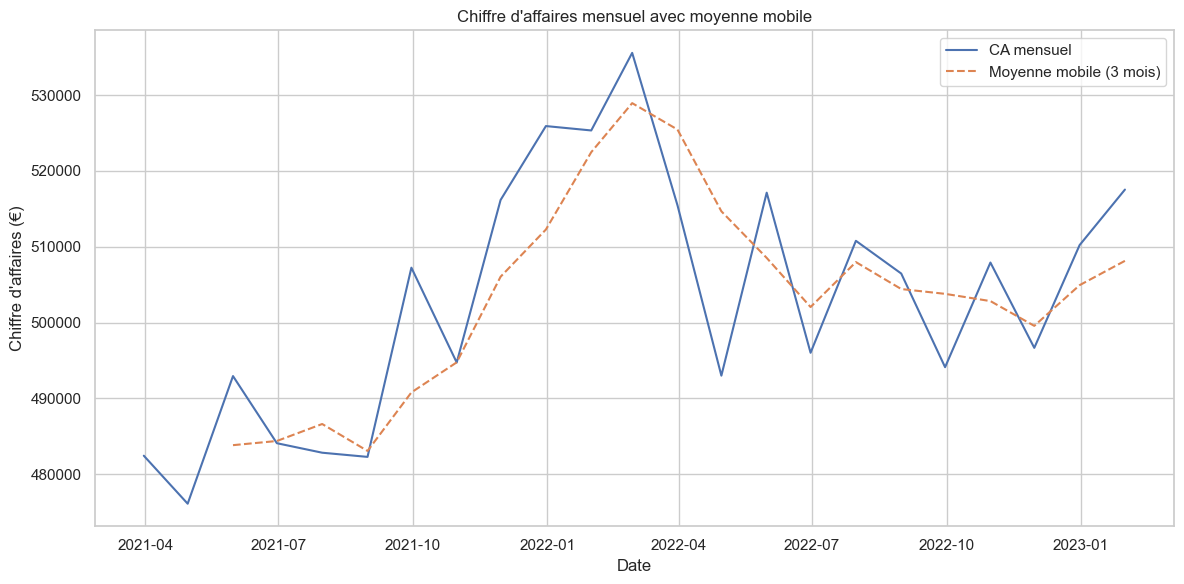

In [27]:
# Conversion en datetime
df_final['date'] = pd.to_datetime(df_final['date'])

# Création d'une colonne "CA" = prix du produit
df_final['ca'] = df_final['price']

# Regrouper par mois
ca_mensuel = df_final.groupby(pd.Grouper(key='date', freq='M'))['ca'].sum().reset_index()
ca_mensuel = ca_mensuel[ca_mensuel['date'] < '2023-02-28']

# Ajout d'une moyenne mobile sur 3 mois
ca_mensuel['ca_moy_mobile_3mois'] = ca_mensuel['ca'].rolling(window=3).mean()

# Affichage graphique
plt.figure(figsize=(12,6))
sns.lineplot(data=ca_mensuel, x='date', y='ca', label='CA mensuel')
sns.lineplot(data=ca_mensuel, x='date', y='ca_moy_mobile_3mois', label='Moyenne mobile (3 mois)', linestyle='--')
plt.title("Chiffre d'affaires mensuel avec moyenne mobile")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Tendance globale** : le CA augmente progressivement jusqu’à un pic autour de fin 2021 / début 2022, puis se stabilise légèrement en 2022.

**Moyenne mobile** : suit bien la tendance, lissage efficace.

#### 2/ Nombre de clients dans le temps
 - par mois

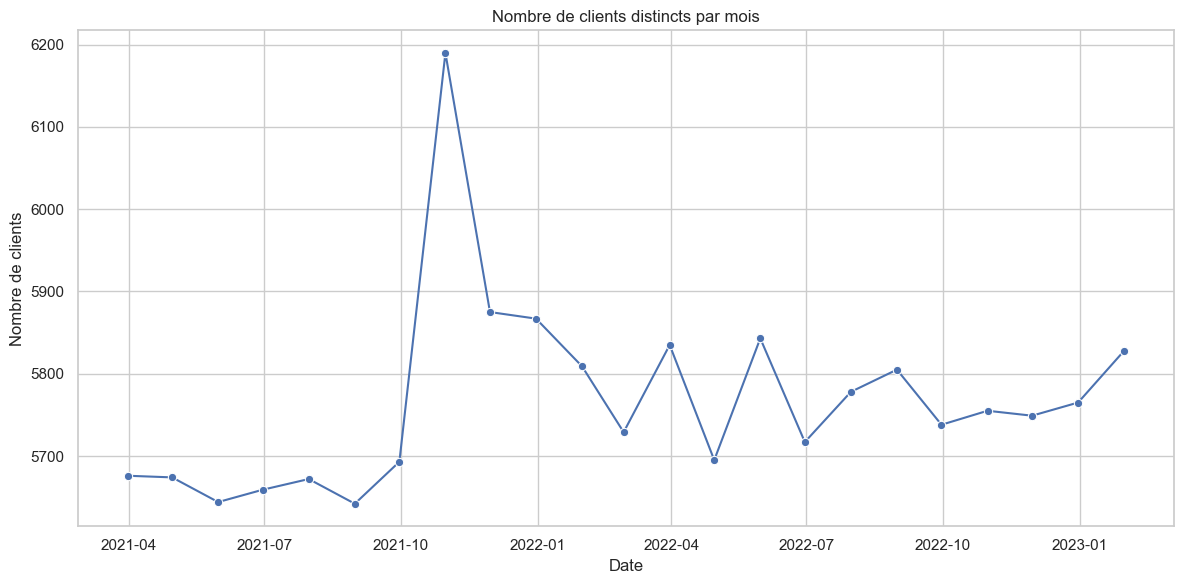

In [28]:
# Nombre de clients distincts par mois
clients_mensuel = df_final.groupby(pd.Grouper(key='date', freq='M'))['client_id'].nunique().reset_index()
clients_mensuel.rename(columns={'client_id': 'nb_clients'}, inplace=True)
clients_mensuel = clients_mensuel[clients_mensuel['date'] < '2023-02-28']

# Affichage
plt.figure(figsize=(12,6))
sns.lineplot(data=clients_mensuel, x='date', y='nb_clients', marker='o')
plt.title("Nombre de clients distincts par mois")
plt.xlabel("Date")
plt.ylabel("Nombre de clients")
plt.grid(True)
plt.tight_layout()
plt.show()

Comportement similaire au CA, avec un bond très net fin 2021, puis une baisse/re-stabilisation.

Ce pic de nouveaux clients pourrait expliquer une hausse du CA → possible effet promo, événement marketing ou opération B2B.

**Approfondissements possibles** :
 - Observer clients nouveaux vs récurrents par mois si possible.

#### 3/ Nombre de transactions par période
 - volume global des opérations

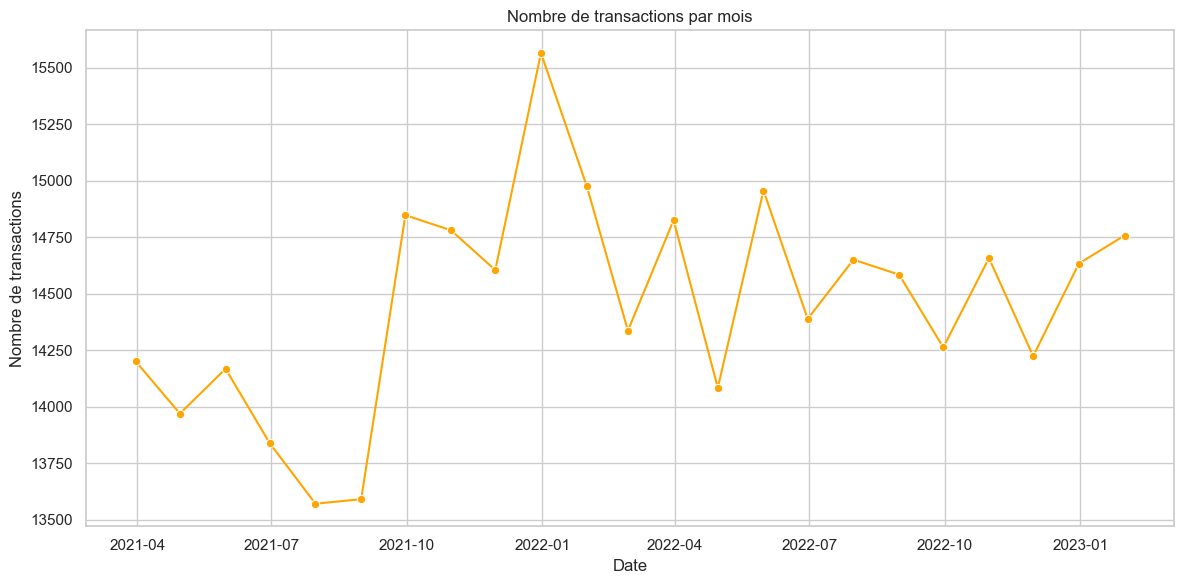

In [29]:
# Une transaction = une ligne dans df_final
transactions_mensuel = df_final.groupby(pd.Grouper(key='date', freq='M'))['session_id'].nunique().reset_index()
transactions_mensuel.rename(columns={'session_id': 'nb_transactions'}, inplace=True)
transactions_mensuel = transactions_mensuel[transactions_mensuel['date'] < '2023-02-28']

# Affichage
plt.figure(figsize=(12,6))
sns.lineplot(data=transactions_mensuel, x='date', y='nb_transactions', marker='o', color='orange')
plt.title("Nombre de transactions par mois")
plt.xlabel("Date")
plt.ylabel("Nombre de transactions")
plt.grid(True)
plt.tight_layout()
plt.show()

Très bon volume autour de fin 2021 (jusqu’à 15 500 transactions/mois) → suit bien la tendance du CA.

Tendance assez stable ensuite, avec des fluctuations régulières.

**Approfondissements possibles** :
 - Ajouter une courbe du panier moyen par mois (CA / nb transactions).
 - Regarder si la valeur moyenne des produits vendus évolue.

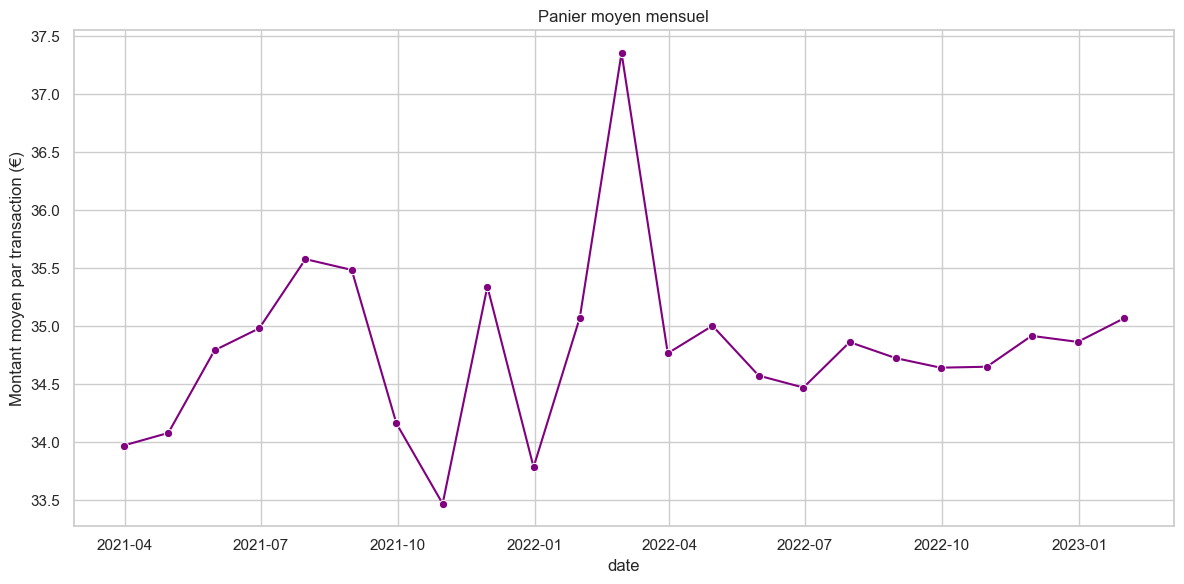

In [30]:
# Panier moyen mensuel

panier_moyen = df_final.groupby(pd.Grouper(key='date', freq='M')).agg(
    ca=('ca', 'sum'),
    nb_transactions=('session_id', 'nunique')
).reset_index()
panier_moyen['panier_moyen'] = panier_moyen['ca'] / panier_moyen['nb_transactions']
panier_moyen = panier_moyen[panier_moyen['date'] < '2023-02-28']

# Affichage
plt.figure(figsize=(12,6))
sns.lineplot(data=panier_moyen, x='date', y='panier_moyen', marker='o', color='purple')
plt.title("Panier moyen mensuel")
plt.ylabel("Montant moyen par transaction (€)")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations** :
Panier moyen autour de 34 à 35 € la majeure partie du temps.

Forte hausse ponctuelle en février 2022 (~37,5 €).

Quelques variations à l’automne 2021 mais globalement, une bonne stabilité.

**Interprétations possibles** :
Le pic de février 2022 peut signaler :
 - des ventes de produits plus chers,
 - une baisse des transactions avec une hausse du CA (=> moins de clients, mais qui ont dépensé plus),
 - ou un mix des deux.

Après février 2022, le panier redescend et se stabilise autour de 34,5 €.

#### 4/ Nombre de produits vendus par période
 - en unités (non CA)

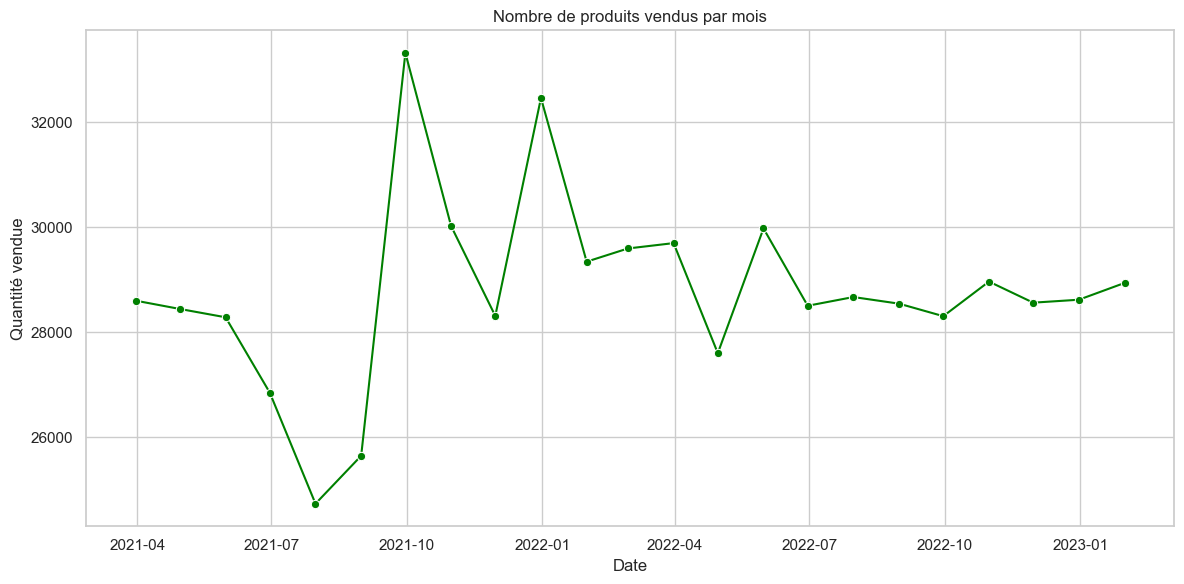

In [31]:
# Une ligne = un produit vendu
produits_mensuel = df_final.groupby(pd.Grouper(key='date', freq='M'))['id_prod'].count().reset_index()
produits_mensuel.rename(columns={'id_prod': 'nb_produits_vendus'}, inplace=True)
produits_mensuel = produits_mensuel[produits_mensuel['date'] < '2023-02-28']

# Affichage
plt.figure(figsize=(12,6))
sns.lineplot(data=produits_mensuel, x='date', y='nb_produits_vendus', marker='o', color='green')
plt.title("Nombre de produits vendus par mois")
plt.xlabel("Date")
plt.ylabel("Quantité vendue")
plt.grid(True)
plt.tight_layout()
plt.show()

Encore une fois, pic autour de fin 2021, suivi d’un plateau.

Les volumes en unités restent importants après le pic, même si plus fluctuants.

Corrélation visuelle avec le CA, mais pas parfaite → il pourrait y avoir des variations de prix moyen.

**Approfondissements possibles** :
 - Calculer le prix moyen par produit vendu par mois (CA / nb produits).
 - Analyser l’évolution des catégories les plus vendues sur la période.

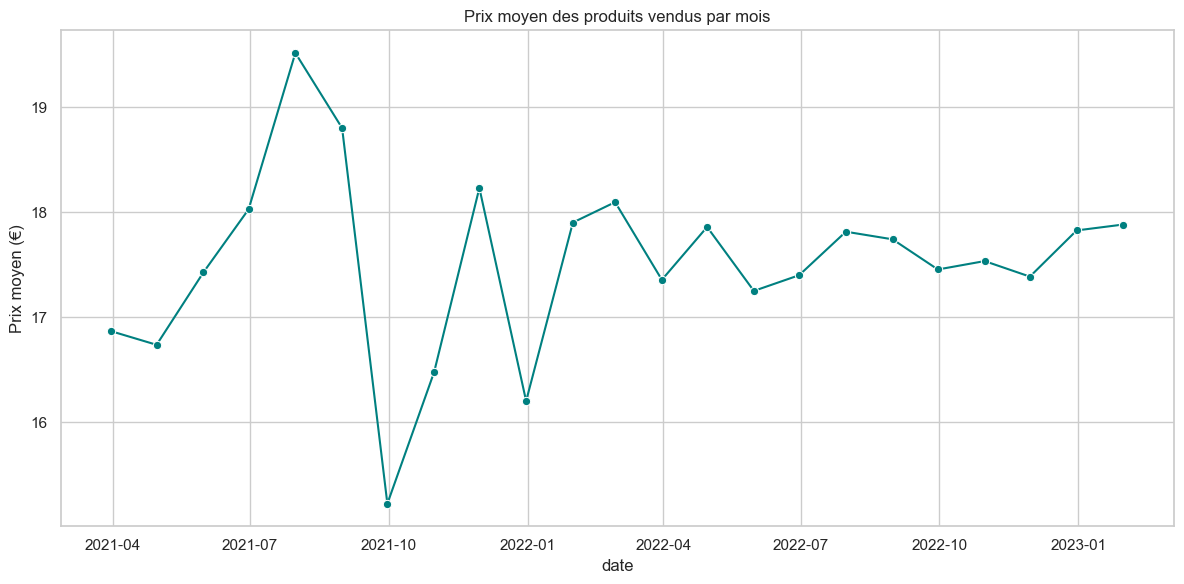

In [32]:
# Prix moyen des produits vendus par mois

prix_moyen = df_final.groupby(pd.Grouper(key='date', freq='M')).agg(
    ca=('ca', 'sum'),
    nb_produits=('id_prod', 'count')
).reset_index()
prix_moyen['prix_moyen'] = prix_moyen['ca'] / prix_moyen['nb_produits']
prix_moyen = prix_moyen[prix_moyen['date'] < '2023-02-28']

# Affichage
plt.figure(figsize=(12,6))
sns.lineplot(data=prix_moyen, x='date', y='prix_moyen', marker='o', color='teal')
plt.title("Prix moyen des produits vendus par mois")
plt.ylabel("Prix moyen (€)")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations** :
Entre 16 € et 19,5 €, avec une grosse instabilité sur les premiers mois (jusqu’à fin 2021).

Ensuite, stabilisation autour de 17,5 à 18 €.

**Interprétations** :
Les pics/creux peuvent traduire :
 - des ventes en masse de produits bas de gamme (ex : septembre 2021) ou au contraire plus chers (juillet-août 2021),
 - des promotions ou offres spéciales,
 - une modification dans le mix produit vendu.

### B - Analyses agrégées par catégories & produits

Objectif : analyser les performances produit et gamme

#### 1/ Chiffre d’affaires par catégorie

 - répartition et/ou tendance

In [33]:
# Palette pour les catégories
palette = sns.color_palette("Set2", 3)

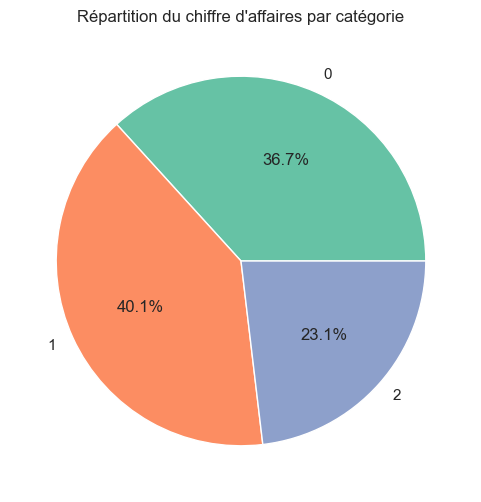

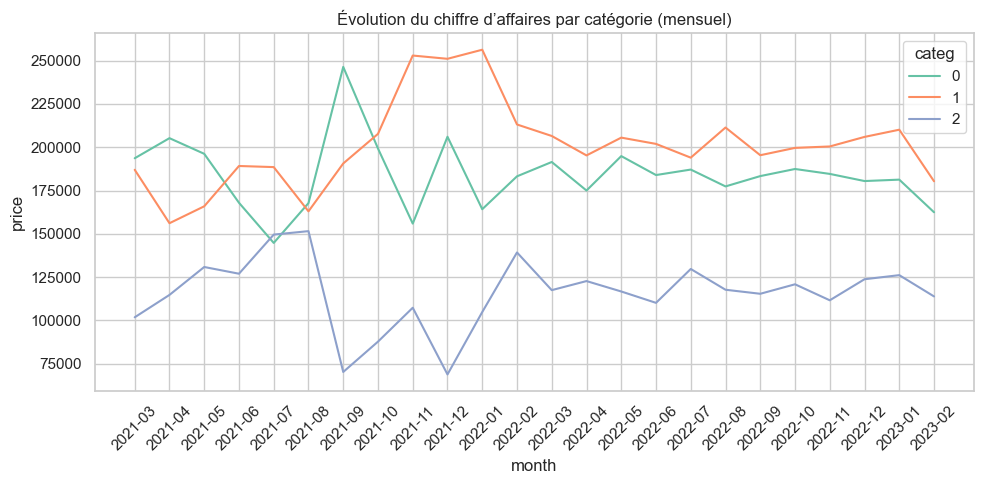

In [34]:
# CA total par catégorie
ca_par_categ = df_final.groupby('categ')['price'].sum().reset_index()

# Répartition en %
ca_par_categ['pct'] = ca_par_categ['price'] / ca_par_categ['price'].sum() * 100

# Visualisation – Répartition en camembert
plt.figure(figsize=(6, 6))
plt.pie(ca_par_categ['price'], labels=ca_par_categ['categ'], autopct='%1.1f%%', colors=palette)
plt.title("Répartition du chiffre d'affaires par catégorie")
plt.show()

# CA mensuel par catégorie (tendance)
df_final['month'] = df_final['date'].dt.to_period('M')
ca_mensuel = df_final.groupby(['month', 'categ'])['price'].sum().reset_index()
ca_mensuel['month'] = ca_mensuel['month'].astype(str)

# Visualisation – Tendance
plt.figure(figsize=(10, 5))
sns.lineplot(data=ca_mensuel, x='month', y='price', hue='categ', palette=palette)
plt.title("Évolution du chiffre d’affaires par catégorie (mensuel)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le **camembert** montre une répartition du CA plutôt équilibrée :
 - La catégorie 1 domine avec 40.1% du chiffre d’affaires.
 - La catégorie 0 suit avec 36.7%, ce qui reste significatif.
 - La catégorie 2, en revanche, ne représente que 23.1% du CA.

**Interprétation** :
Les clients semblent privilégier les livres des catégories 0 et 1. La catégorie 2 génère moins de revenus, ce qui pourrait refléter un intérêt moindre ou une offre moins riche (à croiser avec les volumes de références).

Le **graphe de tendance mensuelle** illustre une saisonnalité et des variations marquées :
 - La catégorie 1 domine de manière constante.
 - La catégorie 0 suit un rythme irrégulier mais reste relativement stable.
 - La catégorie 2 est en retrait tout au long de la période, avec peu de pics.

**Interprétation** :
La tendance confirme la domination de la catégorie 1 sur la durée. Quelques pics saisonniers sont visibles (notamment en fin d’année, période classique de forte demande).

#### 2/ Top des produits (meilleures ventes en CA / unités)

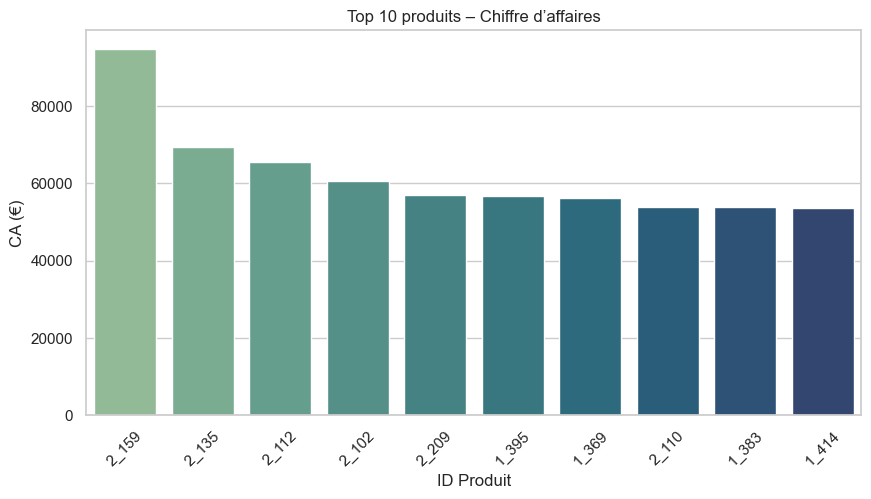

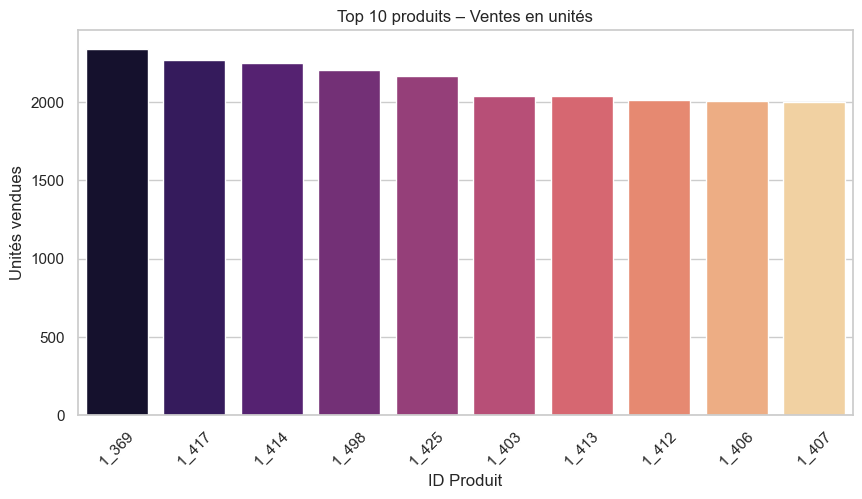

In [35]:
# CA par produit
top_ca = df_final.groupby('id_prod')['price'].sum().sort_values(ascending=False).head(10).reset_index()
# Unités par produit
top_units = df_final.groupby('id_prod')['id_prod'].count().sort_values(ascending=False).head(10).reset_index(name='units_sold')

# Visualisation – Top produits en CA
plt.figure(figsize=(10, 5))
sns.barplot(data=top_ca, x='id_prod', y='price', palette="crest")
plt.title("Top 10 produits – Chiffre d’affaires")
plt.xlabel("ID Produit")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)
plt.show()

# Visualisation – Top produits en unités
plt.figure(figsize=(10, 5))
sns.barplot(data=top_units, x='id_prod', y='units_sold', palette="magma")
plt.title("Top 10 produits – Ventes en unités")
plt.xlabel("ID Produit")
plt.ylabel("Unités vendues")
plt.xticks(rotation=45)
plt.show()

Top 10 en CA : dominé par des produits avec prix unitaire élevé.

Top 10 en unités vendues : dominé par des produits moins chers mais très populaires.

Seulement 2 produits sont communs aux deux classements.

**Interprétation** :
Il y a une dissociation claire entre la popularité d’un produit et sa rentabilité unitaire. Certains produits très populaires (en unités) ne génèrent pas forcément un fort chiffre d’affaires, car leur prix est probablement bas.
Inversement, les produits du top CA peuvent n’avoir été vendus que peu de fois, mais leur valeur unitaire booste leur performance.

On va donc quantifier la différence de positionnement prix entre les deux groupes.

In [36]:
#Prix moyen des produits du top CA vs top unités

# Récupérer les produits des deux tops
top_ca = df_final.groupby('id_prod')['price'].sum().sort_values(ascending=False).head(10).index
top_units = df_final['id_prod'].value_counts().head(10).index

# Prix moyen des produits de chaque groupe
prix_top_ca = df_final[df_final['id_prod'].isin(top_ca)].groupby('id_prod')['price'].mean()
prix_top_units = df_final[df_final['id_prod'].isin(top_units)].groupby('id_prod')['price'].mean()

# Prix médian des produits de chaque groupe
prix_top_ca2 = df_final[df_final['id_prod'].isin(top_ca)].groupby('id_prod')['price'].median()
prix_top_units2 = df_final[df_final['id_prod'].isin(top_units)].groupby('id_prod')['price'].median()

print("Prix moyen - Top CA :", prix_top_ca.mean())
print("Prix moyen - Top Unités :", prix_top_units.mean())
print("Prix médian - Top CA :", prix_top_ca2.median())
print("Prix médian - Top Unités :", prix_top_units2.median())

Prix moyen - Top CA : 57.973
Prix moyen - Top Unités : 20.26
Prix médian - Top CA : 60.695
Prix médian - Top Unités : 19.49


**Interprétation** :

Cela confirme clairement que les produits les plus rentables (en chiffre d’affaires) sont significativement plus chers que ceux qui se vendent le plus en volume.

➕ Les produits du top CA semblent être des produits haut de gamme ou spécialisés, achetés moins souvent mais à un prix élevé.

➖ Les produits du top unités sont probablement des produits d’appel ou populaires, vendus massivement mais à faible marge unitaire.

#### 3/ Flop des produits (faibles ventes ou invendus)

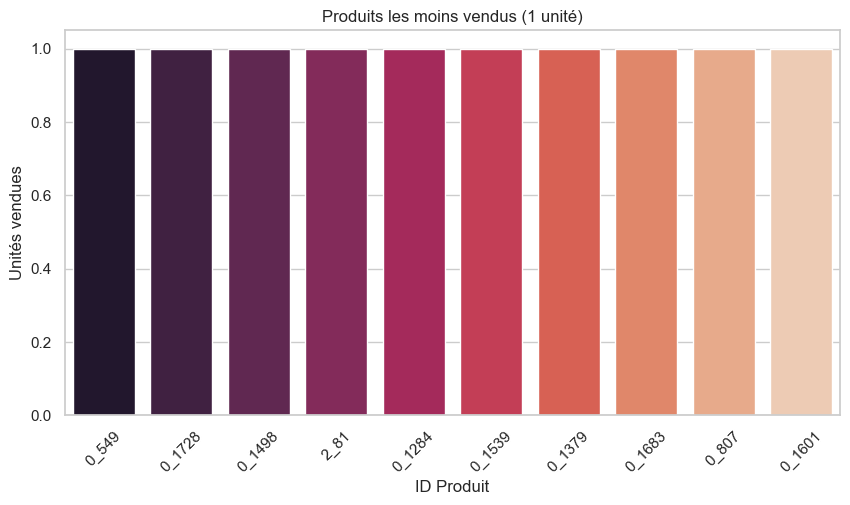

Nombre de produits jamais vendus (invendus) : 0


In [37]:
# Produits vendus au moins une fois
produits_vendus = df_final['id_prod'].value_counts()

# Tous les produits (depuis products.csv si dispo)
# Remplacer si tu as le fichier original :
# all_products = pd.read_csv("products.csv")
# Sinon, on simule :
all_product_ids = df_final['id_prod'].unique()
vendus = produits_vendus.index
invendus = list(set(all_product_ids) - set(vendus))

# Produits avec très peu de ventes (ex : 1 unité)
flop_units = produits_vendus[produits_vendus == 1].reset_index()
flop_units.columns = ['id_prod', 'unit_sold']

plt.figure(figsize=(10, 5))
sns.barplot(data=flop_units.head(10), x='id_prod', y='unit_sold', palette="rocket")
plt.title("Produits les moins vendus (1 unité)")
plt.xlabel("ID Produit")
plt.ylabel("Unités vendues")
plt.xticks(rotation=45)
plt.show()

# Affichage produits jamais vendus
print(f"Nombre de produits jamais vendus (invendus) : {len(invendus)}")

Ce graphe met en avant des produits qui n’ont été vendus qu’une seule fois.

**Interprétation** :
Ces produits pourraient poser problème : absence de demande, mauvaise visibilité ou positionnement, ou simplement des nouveautés. Une analyse complémentaire pourrait identifier les causes (prix ? catégorie ? date d’ajout ?).

#### 4/ Répartition des références par catégorie

 - en CA ou en nombre de produits

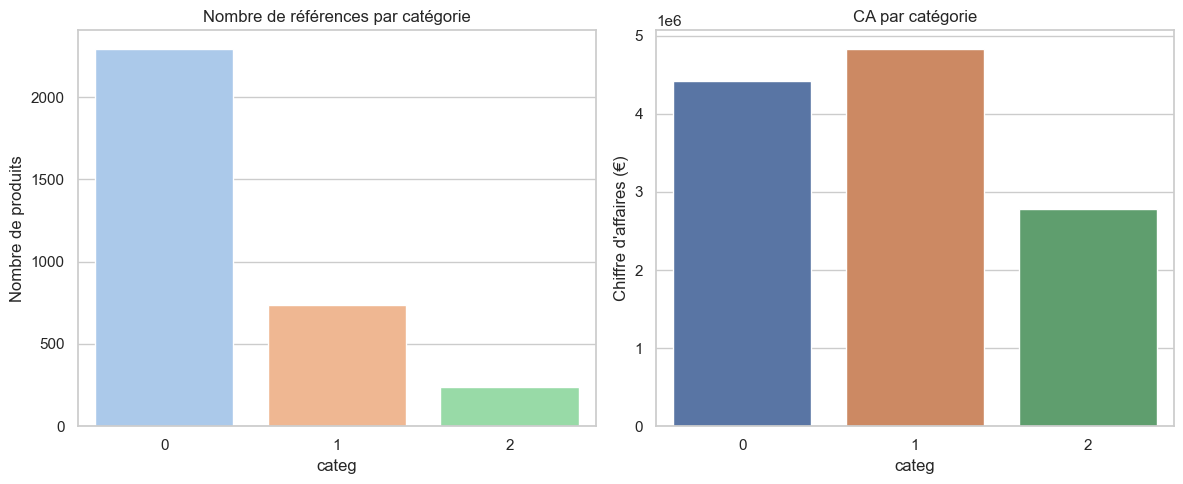

In [38]:
# Nombre de produits par catégorie
nb_produits = df_final.groupby('categ')['id_prod'].nunique().reset_index(name='nb_produits')
# CA par catégorie
ca_par_categ = df_final.groupby('categ')['price'].sum().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Nombre de références
sns.barplot(data=nb_produits, x='categ', y='nb_produits', palette="pastel", ax=ax[0])
ax[0].set_title("Nombre de références par catégorie")
ax[0].set_ylabel("Nombre de produits")

# CA par catégorie
sns.barplot(data=ca_par_categ, x='categ', y='price', palette="deep", ax=ax[1])
ax[1].set_title("CA par catégorie")
ax[1].set_ylabel("Chiffre d'affaires (€)")

plt.tight_layout()
plt.show()

Deux éléments ressortent ici :
 - La catégorie 0 compte le plus de références, loin devant les autres.
 - Pourtant, c’est la catégorie 1 qui génère le plus de CA.

**Interprétation** :
Il y a une surreprésentation de références dans la catégorie 0, mais elles sont moins performantes en CA. Cela indique que la catégorie 1 est plus efficace commercialement (moins de références, meilleur rendement).

On va essayer de voir si certains types de livres (catégories) sont systématiquement plus présents dans le top CA ou top unités.

In [39]:
#Analyse des prix par catégorie

# Catégories des produits top CA et top unités
cat_top_ca = df_final[df_final['id_prod'].isin(top_ca)].groupby('id_prod')['categ'].first().value_counts()
cat_top_units = df_final[df_final['id_prod'].isin(top_units)].groupby('id_prod')['categ'].first().value_counts()

print("Catégories - Top CA :\n", cat_top_ca)
print("Catégories - Top unités :\n", cat_top_units)

Catégories - Top CA :
 categ
2    6
1    4
0    0
Name: count, dtype: int64
Catégories - Top unités :
 categ
1    10
0     0
2     0
Name: count, dtype: int64


Top CA :
 - 6 produits de la catégorie 2
 - 4 produits de la catégorie 1
 - Aucun produit de la catégorie 0

Top unités :
 - 10 produits de la catégorie 1
 - 0 produit des catégories 0 et 2

**Interprétation** :
 - La catégorie 2 domine en valeur mais pas en popularité, ce qui suggère qu’elle contient des livres chers, peut-être plus spécialisés (ex : ouvrages professionnels, beaux livres, etc.).
 - La catégorie 1 est la plus populaire et présente à la fois dans les tops CA et unités : elle semble être polyvalente, avec un bon équilibre prix/popularité.
 - La catégorie 0 est absente des deux tops → elle pourrait représenter des produits peu attractifs ou à faible marge/rotation. Cela mérite une vérification stratégique.

#### 5/ Analyse de concentration (les 10 produits les plus vendus représentent x% du CA)

Les 10 produits les plus vendus représentent 5.17% du chiffre d'affaires total.


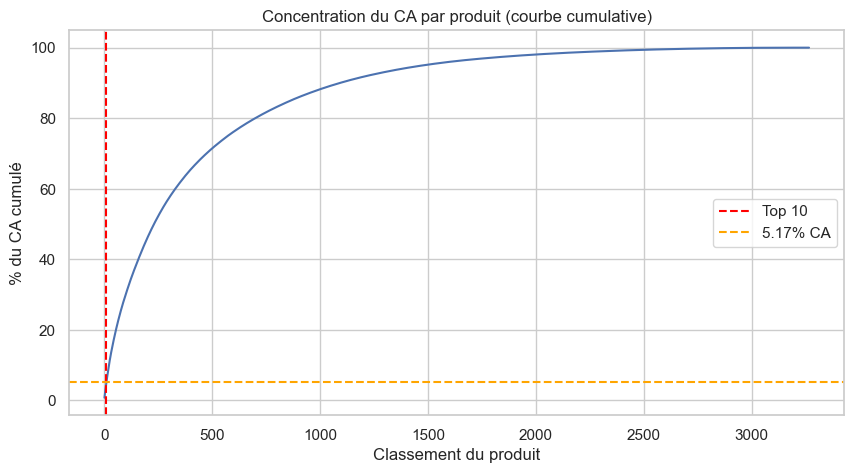

In [40]:
# CA par produit
ca_total = df_final['price'].sum()
ca_par_prod = df_final.groupby('id_prod')['price'].sum().sort_values(ascending=False).reset_index()

# Part du top 10
top10_ca = ca_par_prod.head(10)['price'].sum()
pct_top10 = top10_ca / ca_total * 100

print(f"Les 10 produits les plus vendus représentent {pct_top10:.2f}% du chiffre d'affaires total.")

# Visualisation – courbe de concentration
ca_par_prod['cumulative_ca_pct'] = ca_par_prod['price'].cumsum() / ca_total * 100
ca_par_prod['rank'] = range(1, len(ca_par_prod)+1)

plt.figure(figsize=(10, 5))
sns.lineplot(data=ca_par_prod, x='rank', y='cumulative_ca_pct')
plt.axvline(10, color='red', linestyle='--', label='Top 10')
plt.axhline(pct_top10, color='orange', linestyle='--', label=f'{pct_top10:.2f}% CA')
plt.title("Concentration du CA par produit (courbe cumulative)")
plt.xlabel("Classement du produit")
plt.ylabel("% du CA cumulé")
plt.legend()
plt.show()

La courbe montre que les 10 produits les plus vendus génèrent 5.17% du CA total. La pente au début est assez raide, ce qui signifie que peu de produits concentrent une part non négligeable du chiffre d’affaires.

**Interprétation** :
Il y a une certaine concentration du CA, mais elle n’est pas extrême : le portefeuille produit est relativement diversifié. Cela réduit le risque en cas de déclin d’un produit vedette, mais cela suggère aussi une opportunité de renforcer la performance des meilleurs produits.

On va donc tâcher de repérer les produits qui combinent à la fois un bon volume de ventes ET un bon CA (les vrais "best-sellers").

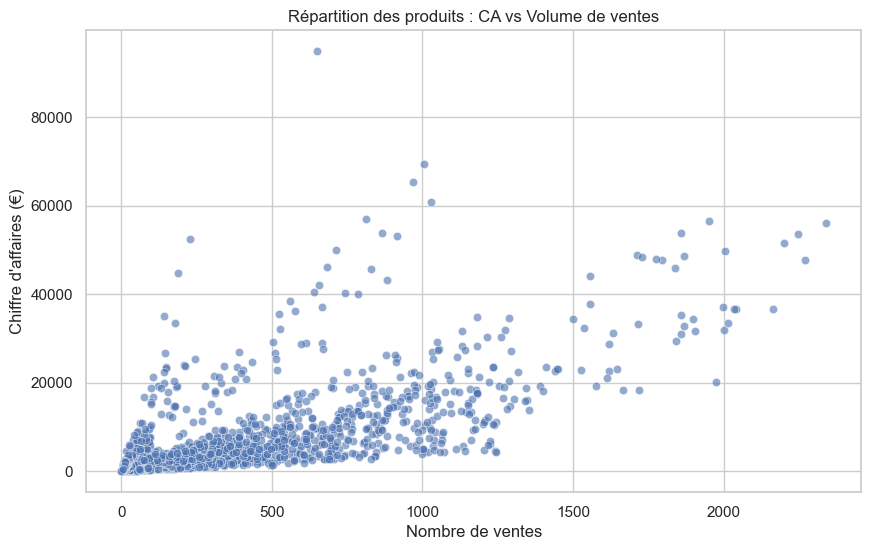

In [41]:
#Analyse croisée CA / volume 

produits_stats = df_final.groupby('id_prod').agg(
    total_ca=('price', 'sum'),
    nb_ventes=('id_prod', 'count')
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=produits_stats, x='nb_ventes', y='total_ca', alpha=0.6)
plt.xlabel("Nombre de ventes")
plt.ylabel("Chiffre d'affaires (€)")
plt.title("Répartition des produits : CA vs Volume de ventes")
plt.grid(True)
plt.show()

Le graphique montre une forte concentration de points en bas à gauche, ce qui traduit une majorité de produits avec peu de ventes et faible CA.

Mais :
 - On distingue une diagonale ascendante floue → les produits avec plus de ventes génèrent logiquement plus de CA, mais ce n’est pas une règle stricte.
 - On observe quelques produits isolés avec CA élevé mais ventes modérées, ce qui confirme encore la valeur unitaire élevée de certains articles.
 - Et quelques points "stars" en haut à droite = produits avec fort volume ET fort CA, potentiels best-sellers stratégiques à surveiller ou promouvoir.

On va également chercher à savoir si quelques produits dominent vraiment ou si les ventes sont uniformément réparties.

In [42]:
#Indice de dispersion du CA produit 

ca_prod = df_final.groupby('id_prod')['price'].sum()
cv = ca_prod.std() / ca_prod.mean()
print("Coefficient de variation du CA produit :", cv)

Coefficient de variation du CA produit : 2.0365349946107862


**Interprétation** :

Le coefficient de variation (CV) est un indicateur de dispersion.
Un CV > 1 signifie que les données sont très dispersées autour de la moyenne.

Ici :

Avec un CV = 2.04, le CA généré par les produits est très hétérogène.

Cela signifie que quelques produits génèrent l’essentiel du chiffre d’affaires, tandis que la majorité contribuent très peu → c’est une situation de concentration commerciale, souvent observée en distribution (règle 80/20).

### C - Analyse orientée clients (sans corrélations)

Objectif : explorer la contribution client sans entrer dans la modélisation

#### 1/ Répartition du chiffre d’affaires B2B

Approche heuristique basée sur le comportement client

Je pourrais poser une hypothèse :
« Un client est probablement B2B si :
 - il effectue un grand nombre d’achats, ou
 - ses achats moyens sont nettement plus élevés que la moyenne, ou
 - il achète plusieurs exemplaires du même produit / même catégorie, ou
 - il achète de façon régulière dans le temps. »

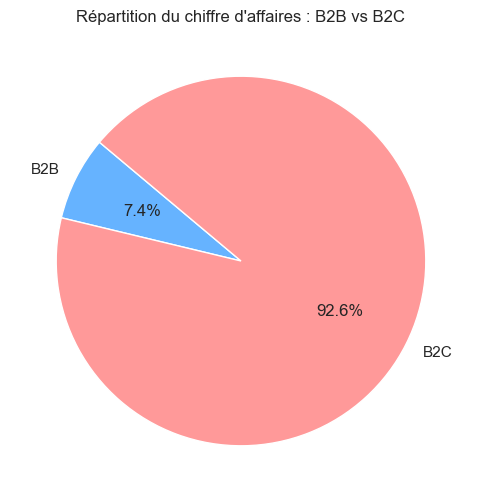

,type_client,ca
0,B2B,884296.09
1,B2C,11143367.01


In [43]:
# On identifie les 4 clients avec le plus de chiffre d'affaires
top_clients_ca = df_final.groupby('client_id')['ca'].sum().sort_values(ascending=False).head(4).index.tolist()

# Ajout d'une colonne 'type_client'
df_final['type_client'] = df_final['client_id'].apply(lambda x: 'B2B' if x in top_clients_ca else 'B2C')

# Répartition du CA B2B vs B2C
ca_b2b_b2c = df_final.groupby('type_client')['ca'].sum().reset_index()

# Visualisation
plt.figure(figsize=(6, 6))
plt.pie(ca_b2b_b2c['ca'], labels=ca_b2b_b2c['type_client'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title("Répartition du chiffre d'affaires : B2B vs B2C")
plt.show()

# Affichage des valeurs
ca_b2b_b2c

**Interprétation** :

B2B représente 7,4% du chiffre d'affaires total.

B2C représente 92,6%, ce qui est logiquement dominant dans une librairie grand public.

Même si les clients B2B sont peu nombreux (4 seulement), ils génèrent une part non négligeable du CA, avec 88 429,09 € de chiffre d’affaires contre 1 114 367,01 € pour les clients B2C.

**Conclusion** :
Cela confirme que les clients B2B ont des commandes de gros volumes, ce qui justifie leur poids relatif élevé malgré leur rareté.

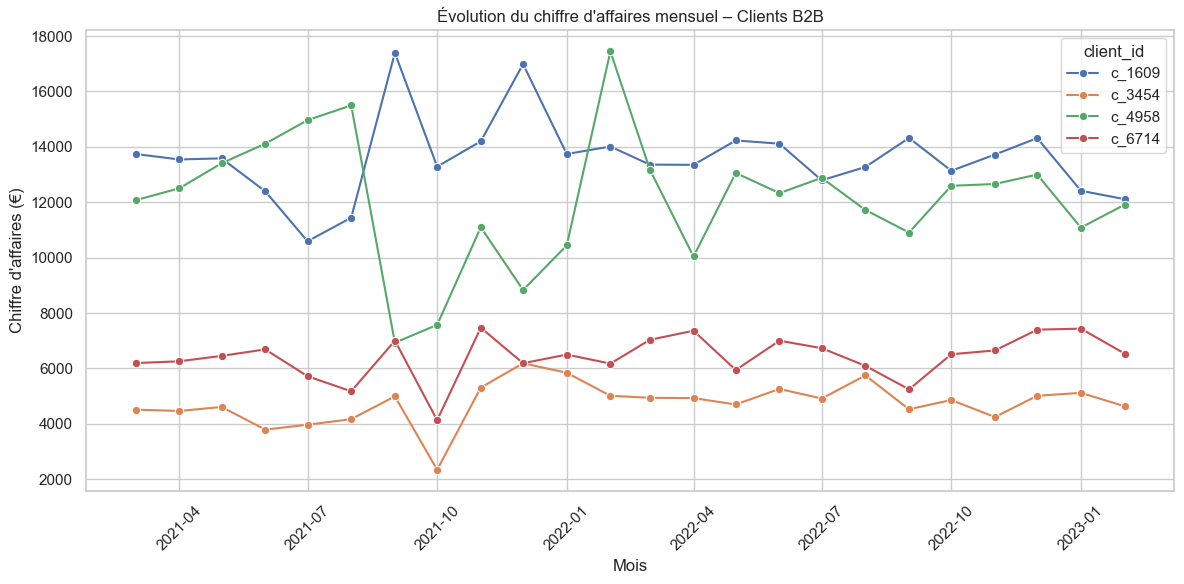

In [44]:
# Extraction des données B2B avec toutes les colonnes
df_b2b = df_final[df_final['type_client'] == 'B2B'].copy()

# S'assurer que la colonne 'month_year' existe
if 'month_year' not in df_b2b.columns:
    df_b2b['month_year'] = df_b2b['date'].dt.to_period('M')

# Convertir month_year en datetime pour l'affichage (milieu du mois)
df_b2b['month_year'] = df_b2b['month_year'].dt.to_timestamp()

# Visualisation de l’évolution mensuelle du CA B2B
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_b2b.groupby(['month_year', 'client_id'])['ca'].sum().reset_index(),
    x='month_year', y='ca', hue='client_id', marker='o'
)
plt.xticks(rotation=45)
plt.title("Évolution du chiffre d'affaires mensuel – Clients B2B")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.grid(True)
plt.tight_layout()
plt.show()

Le graphique présente les 4 clients B2B identifiés, chacun avec son évolution mensuelle de chiffre d’affaires :

Client **c_1609** et **c_4958** sont les plus gros contributeurs, avec un CA mensuel régulier autour de 12 000–17 000 €, malgré quelques variations saisonnières (ex. pic de c_1609 autour de septembre 2021).

Client **c_3454** est le plus petit en volume, avec un CA mensuel stable entre 3 500 € et 5 000 €, ce qui traduit probablement une activité régulière mais modeste.

Client **c_6714** reste intermédiaire, oscillant autour de 6 000–7 000 € avec une bonne stabilité également.

**Conclusion** : Ces 4 clients ont un poids non négligeable malgré leur nombre réduit. Leur stabilité rend le B2B intéressant à surveiller, voire à développer, même s’il ne représente que 7.4 % du CA total.

**Pour la suite de nos analyses on va donc retirer ces 4 clients afin de ne pas biaiser toutes nos interprétations**

In [45]:
# Suppression des 4 clients B2B identifiés
df_final = df_final[~df_final['client_id'].isin(['c_1609', 'c_4958', 'c_3454', 'c_6714'])]

#### 2/ Courbe de Lorenz & indice de Gini

Ce graphique permet d’analyser la concentration des revenus parmi les clients (forte inégalité = forte concentration).

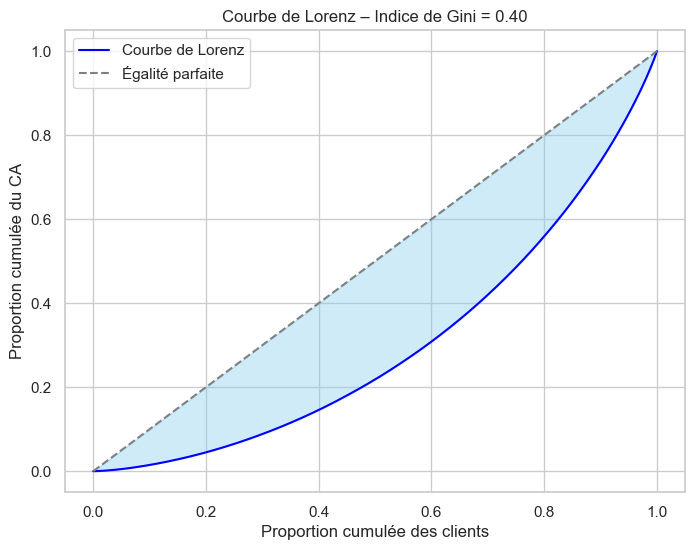

In [46]:
# CA par client
ca_per_client = df_final.groupby('client_id')['ca'].sum().sort_values().values

# Courbe de Lorenz
n = ca_per_client.size
lorenz_curve = np.cumsum(ca_per_client) / ca_per_client.sum()
lorenz_curve = np.insert(lorenz_curve, 0, 0)  # Commence par 0

# Égalité parfaite
x_axis = np.linspace(0.0, 1.0, lorenz_curve.shape[0])

# Indice de Gini
gini_index = 1 - 2 * np.trapz(lorenz_curve, x=x_axis)

# Visualisation
plt.figure(figsize=(8, 6))
plt.plot(x_axis, lorenz_curve, label='Courbe de Lorenz', color='blue')
plt.plot(x_axis, x_axis, label='Égalité parfaite', linestyle='--', color='gray')
plt.fill_between(x_axis, lorenz_curve, x_axis, color='skyblue', alpha=0.4)
plt.title(f"Courbe de Lorenz – Indice de Gini = {gini_index:.2f}")
plt.xlabel("Proportion cumulée des clients")
plt.ylabel("Proportion cumulée du CA")
plt.legend()
plt.grid(True)
plt.show()

**Interprétation** :

La courbe de Lorenz est nettement éloignée de la diagonale, ce qui indique une forte inégalité de distribution du chiffre d'affaires entre les clients.

L’indice de Gini est de 0.40, ce qui signifie :

Une concentration modérée à forte : une partie relativement réduite des clients génère une grande partie du chiffre d’affaires.

Une valeur de 0 indiquerait une égalité parfaite (tous les clients génèrent le même CA), 1 une concentration totale (un seul client fait tout le CA).

**Conclusion** :
La distribution du CA est déséquilibrée, ce qui est typique dans beaucoup d’activités commerciales. Il est donc pertinent de cibler ces clients à forte valeur (B2B ou B2C "premium").

In [47]:
# On exclut les B2B
df_b2c = df_final[df_final['type_client'] == 'B2C']

# CA cumulé par client B2C
b2c_client_ca = df_b2c.groupby('client_id')['ca'].sum().sort_values(ascending=False)

# Calcul du seuil des top 10% (quantile)
seuil = b2c_client_ca.quantile(0.90)

# Identification des clients premium B2C
premium_b2c_ids = b2c_client_ca[b2c_client_ca >= seuil].index.tolist()
print(f"{len(premium_b2c_ids)} clients identifiés comme B2C premium.")

display(premium_b2c_ids)

860 clients identifiés comme B2C premium.


['c_1570',
 'c_3263',
 'c_2140',
 'c_2899',
 'c_7319',
 'c_7959',
 'c_1422',
 'c_7421',
 'c_8026',
 'c_2505',
 'c_1876',
 'c_4491',
 'c_5263',
 'c_2595',
 'c_8392',
 'c_880',
 'c_8510',
 'c_1636',
 'c_2077',
 'c_4840',
 'c_5953',
 'c_6646',
 'c_1637',
 'c_760',
 'c_3028',
 'c_632',
 'c_794',
 'c_3030',
 'c_8600',
 'c_8537',
 'c_3892',
 'c_634',
 'c_4142',
 'c_5602',
 'c_8556',
 'c_7773',
 'c_7390',
 'c_2212',
 'c_3430',
 'c_778',
 'c_7240',
 'c_1413',
 'c_3725',
 'c_6977',
 'c_1893',
 'c_6775',
 'c_5898',
 'c_1823',
 'c_161',
 'c_391',
 'c_8501',
 'c_669',
 'c_1767',
 'c_428',
 'c_6522',
 'c_707',
 'c_963',
 'c_2284',
 'c_3612',
 'c_1368',
 'c_6249',
 'c_5674',
 'c_4023',
 'c_8193',
 'c_243',
 'c_8159',
 'c_50',
 'c_3290',
 'c_5935',
 'c_6',
 'c_5921',
 'c_580',
 'c_2538',
 'c_6573',
 'c_6409',
 'c_4669',
 'c_3347',
 'c_7244',
 'c_3699',
 'c_5993',
 'c_2982',
 'c_7150',
 'c_6536',
 'c_7208',
 'c_8163',
 'c_6407',
 'c_1149',
 'c_8327',
 'c_6950',
 'c_1410',
 'c_1240',
 'c_5279',
 'c_222

**Interprétation** : 

Ces clients B2C premium sont essentiels à analyser car :
 - Ils peuvent concentrer une large part du CA (effet Pareto).
 - Ils sont probablement moins sensibles au prix ou plus fidèles.
 - Un ciblage marketing ou une offre personnalisée pourrait renforcer leur engagement.

#### 3/ Chiffre d’affaires moyen par client

Chiffre d'affaires moyen par client : 1296.34 €


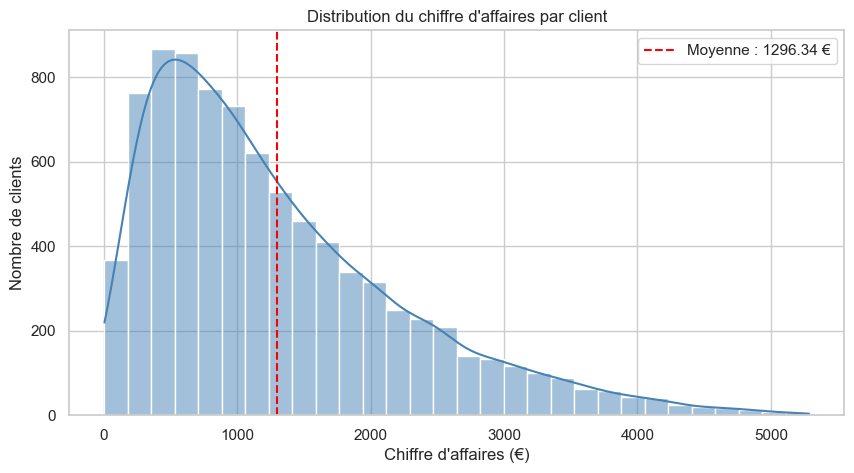

In [48]:
# CA moyen par client
ca_moyen = df_final.groupby('client_id')['ca'].sum().mean()
print(f"Chiffre d'affaires moyen par client : {ca_moyen:.2f} €")

# Optionnel : histogramme des CA client
plt.figure(figsize=(10, 5))
sns.histplot(df_final.groupby('client_id')['ca'].sum(), bins=30, kde=True, color='steelblue')
plt.axvline(ca_moyen, color='red', linestyle='--', label=f'Moyenne : {ca_moyen:.2f} €')
plt.title("Distribution du chiffre d'affaires par client")
plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("Nombre de clients")
plt.legend()
plt.grid(True)
plt.show()

**Résultat** :

Le CA moyen par client est de 1296.34 €.

L’histogramme montre :

Une forte concentration de clients avec un CA faible.

Quelques clients avec des valeurs très élevées (effet "long tail"), probablement les B2B ou les meilleurs clients B2C.

La moyenne est donc tirée vers le haut par ces gros clients, alors que la plupart des clients achètent peu.

**Conclusion** :
Le CA moyen n'est pas représentatif du client "typique" à cause des disparités.

Il peut être pertinent de segmenter les clients ou de regarder la médiane du CA pour compléter cette analyse.

In [49]:
ca_par_client = df_final.groupby('client_id')['ca'].sum()
ca_moyenne = ca_par_client.mean()
ca_mediane = ca_par_client.median()

print(f"CA moyen : {ca_moyenne:.2f} €")
print(f"CA médian : {ca_mediane:.2f} €")

CA moyen : 1296.34 €
CA médian : 1045.59 €


**Interprétation** :

Le fait que le moyen > médian indique une distribution asymétrique à droite, typique des données économiques :

Beaucoup de clients dépensent peu,

Une minorité dépense beaucoup et tire la moyenne vers le haut.

### D - Analyse de saisonnalité produit / catégorie

#### 1/ Produits les plus achetés selon les périodes de l’année (ex : Noël, rentrée scolaire, etc.)

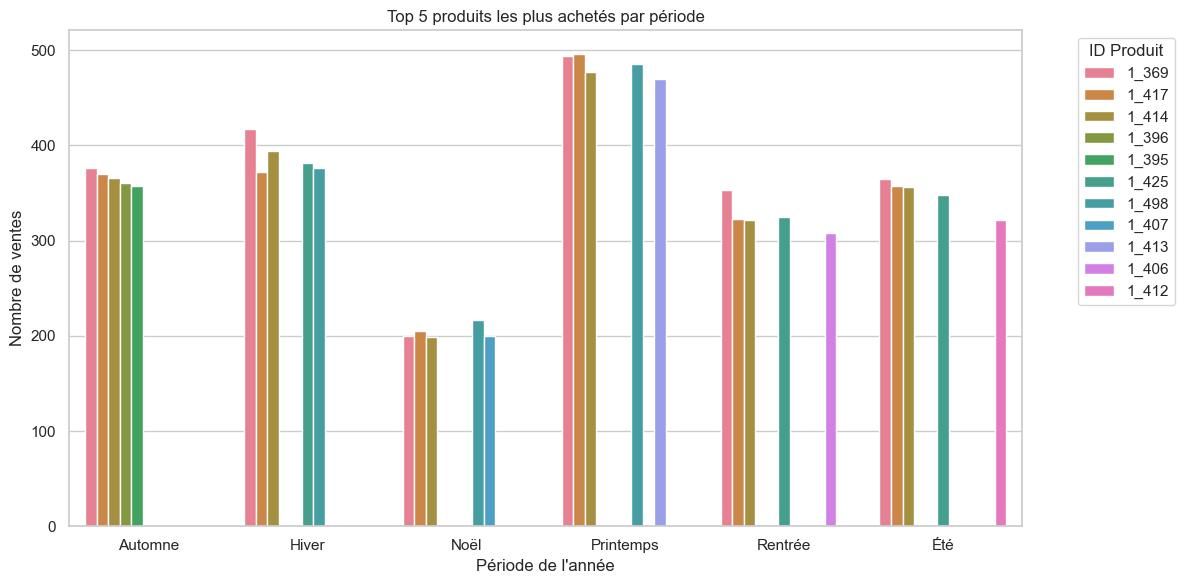

In [50]:
# Ajout des colonnes temporelles
df_final['month'] = df_final['date'].dt.month
df_final['year'] = df_final['date'].dt.year
df_final['month_year'] = df_final['date'].dt.to_period('M')

# Pour détecter des périodes comme Noël, rentrée, etc.
df_final['periode'] = df_final['month'].map({
    1: 'Hiver',
    2: 'Hiver',
    3: 'Printemps',
    4: 'Printemps',
    5: 'Printemps',
    6: 'Été',
    7: 'Été',
    8: 'Rentrée',
    9: 'Rentrée',
    10: 'Automne',
    11: 'Automne',
    12: 'Noël'
})

# Top 5 produits les plus vendus par période (en volume)
top_products_by_period = df_final.groupby(['periode', 'id_prod']).size().reset_index(name='nb_ventes')
top5_by_period = top_products_by_period.sort_values(['periode', 'nb_ventes'], ascending=[True, False])\
                                       .groupby('periode').head(5)

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(data=top5_by_period, x='periode', y='nb_ventes', hue='id_prod', dodge=True)
plt.title('Top 5 produits les plus achetés par période')
plt.xlabel('Période de l\'année')
plt.ylabel('Nombre de ventes')
plt.legend(title='ID Produit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observations** :
 - Certains produits (comme 1_369 et 1_417) apparaissent de manière récurrente dans plusieurs saisons (Automne, Hiver, Printemps, Été).
 - À Noël, on observe une baisse notable du nombre de ventes sur tous les produits — ce qui est surprenant si on s’attendait à un pic (potentiellement un effet produit par la typologie des biens vendus ?).
 - Le printemps semble être la période la plus dynamique en termes de volume pour plusieurs produits.
 - Les produits mis en avant changent légèrement selon la période, mais certains restent dans le top toute l’année → ce sont probablement des best-sellers toute saison.

**Interprétations** :
 - Il y a des produits phares qui ne dépendent pas trop de la saison.
 - La période de Noël pourrait être optimisée (promotion ? assortiment ?) car elle ne génère pas un pic évident ici.
 - Potentiel à identifier des produits saisonniers à développer davantage (s’ils sont sous-représentés actuellement).

#### 2/ Catégories les plus populaires par mois / trimestre

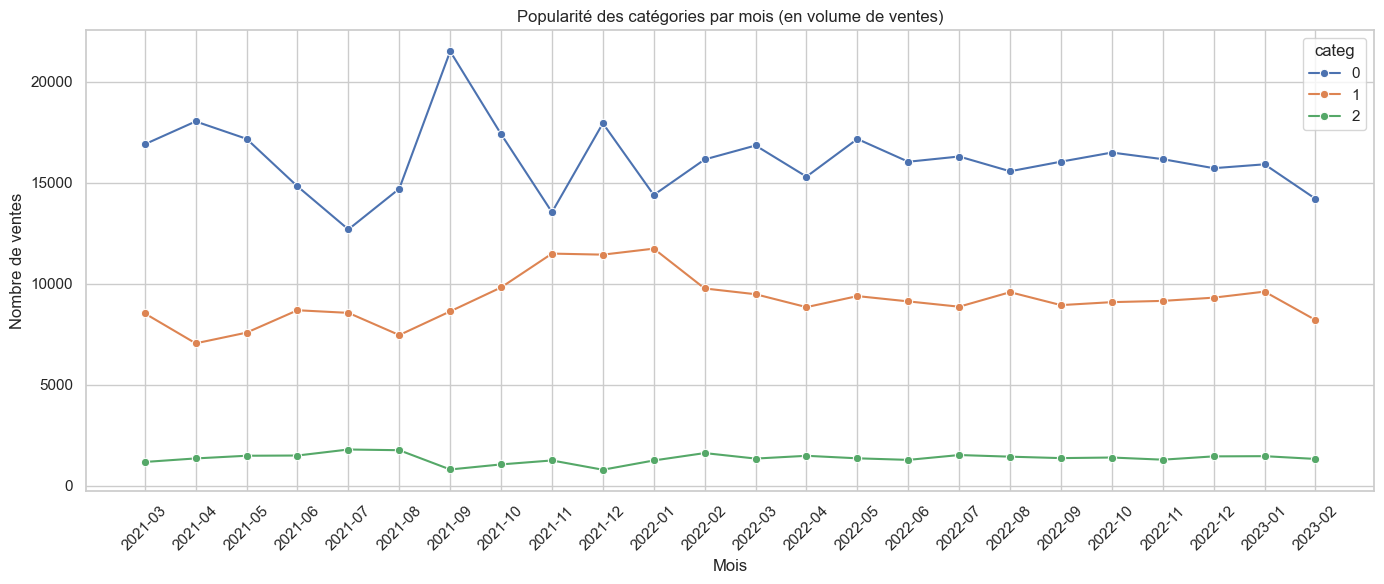

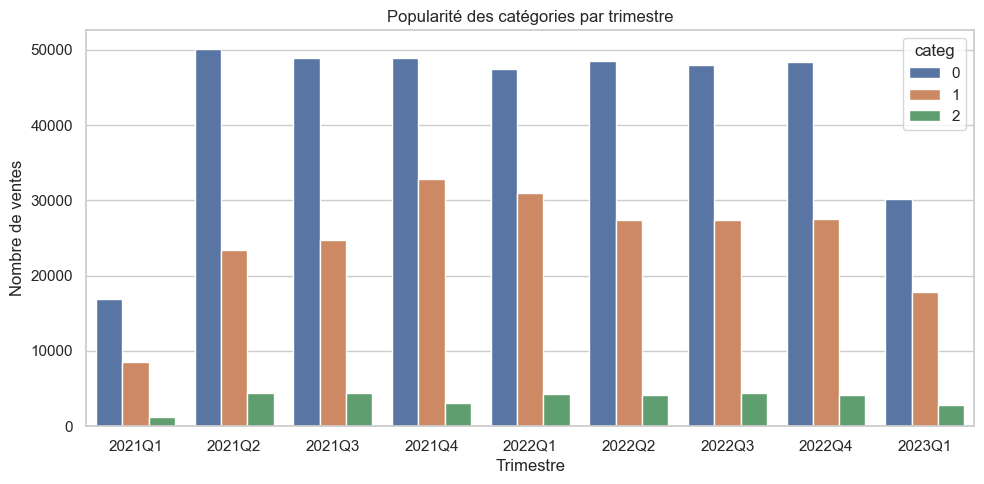

In [51]:
# Ajout d'une colonne trimestre
df_final['quarter'] = df_final['date'].dt.to_period('Q')

# === Répartition mensuelle ===
monthly_categ = df_final.groupby(['month_year', 'categ']).size().reset_index(name='nb_ventes')
monthly_categ['month_year'] = monthly_categ['month_year'].astype(str)
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_categ, x='month_year', y='nb_ventes', hue='categ', marker="o")
plt.title('Popularité des catégories par mois (en volume de ventes)')
plt.xlabel('Mois')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Répartition trimestrielle ===
quarterly_categ = df_final.groupby(['quarter', 'categ']).size().reset_index(name='nb_ventes')
plt.figure(figsize=(10, 5))
sns.barplot(data=quarterly_categ, x='quarter', y='nb_ventes', hue='categ')
plt.title('Popularité des catégories par trimestre')
plt.xlabel('Trimestre')
plt.ylabel('Nombre de ventes')
plt.tight_layout()
plt.show()

**Popularité des catégories par mois**

**Observations** :
 - Catégorie 0 (ligne bleue) domine très largement, avec une stabilité assez forte tout au long de l’année.
 - Catégorie 1 (orange) reste en 2ᵉ position avec un volume régulier, mais plus bas (~8 000 - 10 000 ventes / mois).
 - Catégorie 2 (verte) reste marginale, très peu vendue.

**Interprétation** :
 - Aucune forte saisonnalité mensuelle apparente à première vue pour les catégories (sauf quelques pics ponctuels, par ex. août 2021 et avril 2022 pour la catégorie 0).
 - Il serait intéressant de croiser avec les pics de CA pour voir si certaines périodes voient peu de ventes mais des paniers plus élevés (prix moyen ↑).
 - La catégorie 2 est structurellement faible, et mériterait peut-être une remise en question de sa pertinence commerciale ou de son offre produit.

**Popularité des catégories par trimestre**

**Observations** :
Le schéma par trimestre confirme les tendances vues par mois :
 - Catégorie 0 est largement dominante.
 - Catégorie 1 est stable en 2ᵉ position.
 - Catégorie 2 reste très marginale.

Légère baisse globale des ventes en 2023Q1, à noter si cela se confirme sur les mois suivants.

**Interprétation** :
Ce graphique met bien en évidence que la structure des ventes est constante trimestre après trimestre, sans bascule saisonnière majeure entre catégories.
Il pourrait être utile de :
 - Vérifier si les marges sont aussi favorables sur la catégorie dominante.
 - Explorer pourquoi la catégorie 2 est si faible : offre ? visibilité ? positionnement prix ?

### E – Analyse de fidélité produit / panier

#### 1/ Nombre de clients ayant acheté plusieurs fois le même produit

In [52]:
# On compte le nombre d’achats par client et par produit
repeat_purchase = df_final.groupby(['client_id', 'id_prod']).size().reset_index(name='nb_achats')

# On ne garde que les cas où un client a acheté un même produit plusieurs fois
repeat_purchase_filtered = repeat_purchase[repeat_purchase['nb_achats'] > 1]

# On calcule le nombre de clients fidèles par produit
clients_fideles_par_produit = repeat_purchase_filtered.groupby('id_prod')['client_id'].nunique().reset_index()
clients_fideles_par_produit.columns = ['id_prod', 'nb_clients_fideles']
print(clients_fideles_par_produit)

     id_prod  nb_clients_fideles
0        0_0                 351
1        0_1                 144
2       0_10                   5
3      0_100                   1
4     0_1000                 119
5     0_1001                 117
6     0_1002                 138
7     0_1003                 124
8     0_1004                 124
9     0_1005                   1
10    0_1006                   3
11    0_1007                 124
12    0_1008                 105
13    0_1009                 131
14     0_101                   6
15    0_1010                   2
16    0_1011                 127
17    0_1012                   1
18    0_1013                 130
19    0_1015                 132
20    0_1017                 122
21    0_1018                 114
22    0_1019                   3
23     0_102                   5
24    0_1020                 120
25    0_1021                 117
26    0_1022                   4
27    0_1023                 156
28    0_1024                   1
29    0_10

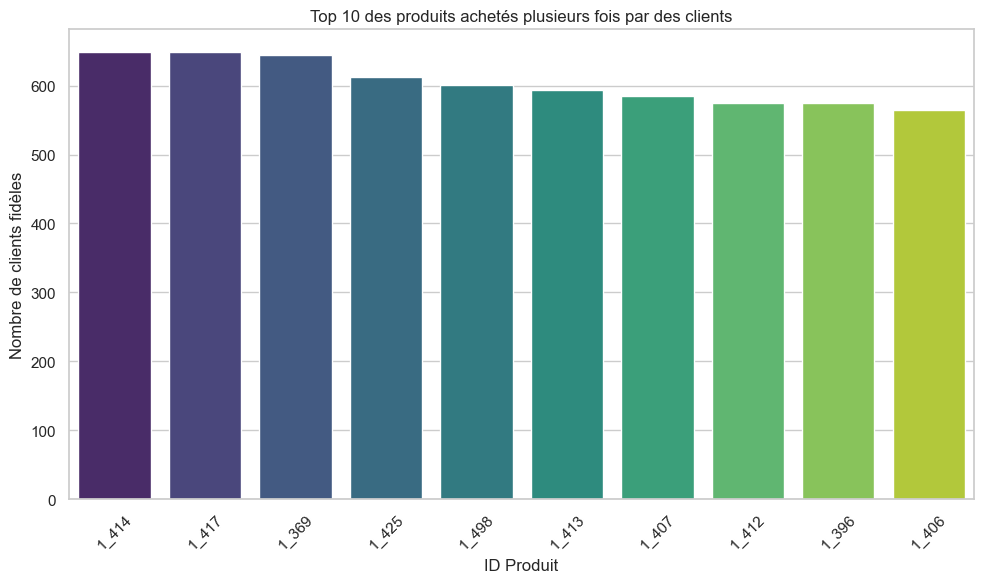

In [53]:
# Top 10 produits les plus "fidélisants"
top_fideles = clients_fideles_par_produit.sort_values(by='nb_clients_fideles', ascending=False).head(10)

# Visualisation
plt.figure(figsize=(10,6))
sns.barplot(data=top_fideles, x='id_prod', y='nb_clients_fideles', palette='viridis')
plt.title("Top 10 des produits achetés plusieurs fois par des clients")
plt.xlabel("ID Produit")
plt.ylabel("Nombre de clients fidèles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Lecture** :

Ce graphique montre les produits les plus souvent achetés à plusieurs reprises par les mêmes clients (fidélité produit).

Le top 3 est constitué des produits avec les ID : 1_414, 1_417, 1_369.

Chaque produit du top 10 a été racheté par environ 570 à 650 clients différents, ce qui est significatif.


**Interprétation** :
Ces produits ont une forte fidélisation : ils sont probablement perçus comme des "valeurs sûres" ou présentent des qualités qui incitent les clients à les racheter.
Cela peut signifier :
 - un excellent rapport qualité/prix,
 - une utilité ou un attrait récurrent (ex. livres de référence, séries ou produits pédagogiques),
 - ou simplement une très bonne réception client.

**À faire** : Ces produits sont à surveiller / valoriser dans une stratégie de recommandation ou de mise en avant (promotions, suggestions personnalisées, etc.).

#### 2/ Répartition du panier moyen par catégorie de livre

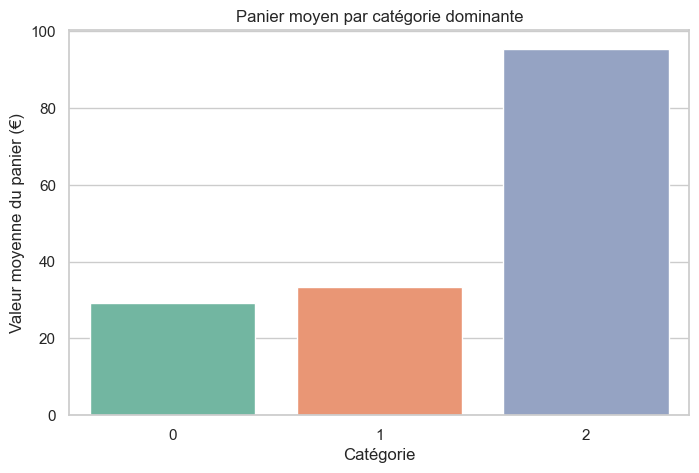

In [54]:
# Panier total par session (= commande)
panier_par_session = df_final.groupby(['session_id']).agg({'price': 'sum'}).reset_index()
panier_par_session.columns = ['session_id', 'valeur_panier']

# On identifie la catégorie dominante (la plus présente) dans chaque session
dominante_categ = df_final.groupby(['session_id', 'categ']).size().reset_index(name='nb_produits')
dominante_categ = dominante_categ.sort_values(['session_id', 'nb_produits'], ascending=[True, False])
dominante_categ_unique = dominante_categ.drop_duplicates('session_id')

# Fusion des deux
panier_categ = panier_par_session.merge(dominante_categ_unique[['session_id', 'categ']], on='session_id')

# Calcul du panier moyen par catégorie dominante
panier_moyen_categ = panier_categ.groupby('categ')['valeur_panier'].mean().reset_index()

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(data=panier_moyen_categ, x='categ', y='valeur_panier', palette='Set2')
plt.title("Panier moyen par catégorie dominante")
plt.xlabel("Catégorie")
plt.ylabel("Valeur moyenne du panier (€)")
plt.show()

**Lecture** :

Les paniers où la catégorie dominante est la 2 ont une valeur moyenne bien plus élevée (≈95 €).

En comparaison :
 - Catégorie 0 : ~28 €
 - Catégorie 1 : ~33 €

**Interprétation** :

Quand un client achète principalement des produits de catégorie 2, il dépense beaucoup plus. Cela indique que cette catégorie contient :
 - des produits plus chers,
 - ou des combinaisons de produits qui poussent à l’achat groupé.

Les paniers dominés par les catégories 0 et 1 restent dans une gamme de prix relativement basse et homogène.

**À explorer** :
 - Que contient la catégorie 2 ? (Type de livres, usage, cible…)
 - Peut-on pousser certains profils vers cette catégorie ?
 - Peut-on construire des offres spéciales autour de cette catégorie pour augmenter le panier moyen ?

## Partie 5 - Analyses plus ciblées sur les clients

### A – Corrélations portants sur l’âge des clients

#### 1/ Corrélation entre l’âge et le montant total des achats

In [55]:
from datetime import datetime

# Calcul de l'âge
df_final['age'] = datetime.now().year - df_final['birth_year']

# Montant total des achats par client
total_achats = df_final.groupby('client_id').agg({
    'price': 'sum',
    'age': 'first'  # l'âge est constant pour un client
}).reset_index()

# Corrélation
corr1 = total_achats[['age', 'price']].corr().iloc[0, 1]
print("Corrélation âge / montant total des achats :", corr1)

Corrélation âge / montant total des achats : -0.18756654332685224


**Interprétation** :
Cette corrélation est faible et négative, donc aucune relation significative n’apparaît entre l’âge des clients et leur montant total dépensé. Cela signifie que les jeunes et les moins jeunes dépensent globalement des montants comparables.

In [56]:
from scipy.stats import pearsonr

# 1. Regrouper les données par client pour obtenir l'âge et le total d'achat
df_client = df_final.groupby('client_id').agg({
    'age': 'first',  # l'âge reste constant par client
    'ca': 'sum'      # somme du chiffre d'affaires par client
}).reset_index()

# 2. Test de corrélation de Pearson
corr, p_value = pearsonr(df_client['age'], df_client['ca'])

print(f"Coefficient de corrélation de Pearson : {corr:.6f}")
print(f"P-value : {p_value:.6f}")

# Optionnel : interprétation automatique
alpha = 0.05
if p_value < alpha:
    print("Résultat : Corrélation significative (on rejette H0)")
else:
    print("Résultat : Pas de corrélation significative (on ne rejette pas H0)")

Coefficient de corrélation de Pearson : -0.187567
P-value : 0.000000
Résultat : Corrélation significative (on rejette H0)


**Interprétation** :

Il existe une corrélation linéaire faible mais statistiquement significative entre l’âge des clients et le montant total de leurs achats :

Le coefficient de -0.188 indique une corrélation négative faible : plus l'âge augmente, plus le montant total dépensé tend à légèrement diminuer.

La p-value extrêmement faible (≈ 0) indique que cette relation est statistiquement significative : on peut rejeter l’hypothèse nulle H₀ (absence de corrélation), avec un niveau de confiance élevé (α = 0.05).

**À garder en tête** :

Même si la corrélation est significative, sa valeur absolue est faible : cela signifie que l’âge n’explique qu’une très faible part de la variation du montant des achats.

Ce type de corrélation pourrait être influencé par des variables confondantes : par exemple, habitudes de consommation liées à l’âge, préférences de catégories, pouvoir d’achat, etc.

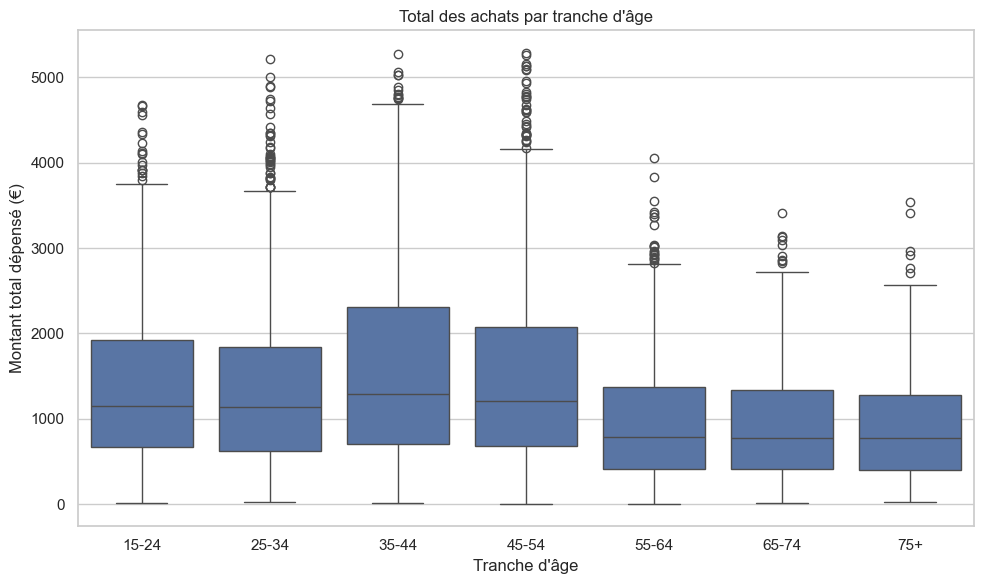

In [57]:
#Visualisation des distributions du total des achats par tranches d’âge (boxplot)

# Définir les tranches d’âge
bins = [15, 25, 35, 45, 55, 65, 75, 100]
labels = ['15-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
df_final['age_group'] = pd.cut(df_final['age'], bins=bins, labels=labels, right=False)

# Total des achats par client
total_achats = df_final.groupby('client_id')['price'].sum().reset_index()
total_achats = total_achats.merge(df_final[['client_id', 'age_group']].drop_duplicates(), on='client_id')

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=total_achats, x='age_group', y='price')
plt.title("Total des achats par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Montant total dépensé (€)")
plt.tight_layout()
plt.show()

**Lecture** :
Médiane la plus élevée : chez les 35–44 ans, suivis de près par les 45–54 ans.

Tranches 15–34 ans : médiane légèrement inférieure, mais relativement proche.

À partir de 55 ans : baisse claire du montant total dépensé, avec une médiane plus faible et une distribution plus resserrée.

Amplitude (écart interquartile) : relativement stable jusqu’à 54 ans, puis diminue chez les plus âgés.

**Interprétation** :
Les personnes de 35 à 54 ans sont celles qui dépensent le plus globalement. Cela pourrait s’expliquer par un pouvoir d’achat plus élevé et une consommation culturelle stable.

Après 55 ans, on observe une baisse du montant total dépensé, probablement liée à un changement de comportement ou de priorités de consommation.
Les plus jeunes (15–24 ans) dépensent un peu moins, mais restent dans une fourchette comparable.

#### 2/ Corrélation entre l’âge et la fréquence d’achat

In [58]:
# Fréquence d'achat = nombre de sessions différentes
freq_achat = df_final.groupby('client_id').agg({
    'session_id': pd.Series.nunique,
    'age': 'first'
}).reset_index()
freq_achat.rename(columns={'session_id': 'nb_sessions'}, inplace=True)

# Corrélation
corr2 = freq_achat[['age', 'nb_sessions']].corr().iloc[0, 1]
print("Corrélation âge / fréquence d’achat :", corr2)

Corrélation âge / fréquence d’achat : 0.16449131101203018


**Interprétation** :
Même situation ici : corrélation très faible et légèrement positive. Cela suggère que les personnes plus âgées ont légèrement tendance à acheter plus souvent, mais la relation est quasiment nulle.

In [59]:
from scipy.stats import pearsonr

# Test de corrélation de Pearson entre l'âge et la fréquence d'achat
corr_freq, p_value_freq = pearsonr(freq_achat['age'], freq_achat['nb_sessions'])

print(f"Coefficient de corrélation de Pearson : {corr_freq:.6f}")
print(f"P-value : {p_value_freq:.6f}")

# Interprétation simple
alpha = 0.05
if p_value_freq < alpha:
    print("Résultat : Corrélation significative (on rejette H0)")
else:
    print("Résultat : Pas de corrélation significative (on ne rejette pas H0)")

Coefficient de corrélation de Pearson : 0.164491
P-value : 0.000000
Résultat : Corrélation significative (on rejette H0)


**Interprétation** :

Il existe une corrélation linéaire positive faible mais statistiquement significative entre l’âge des clients et leur fréquence d’achat :

Le coefficient de corrélation de +0.164 indique qu’en moyenne, les clients plus âgés ont tendance à effectuer légèrement plus de sessions d’achat.

La p-value extrêmement faible (≈ 0) permet de rejeter l’hypothèse nulle H₀, confirmant que cette corrélation n’est pas due au hasard (au seuil de 5%).

**À noter**

Bien que la relation soit statistiquement significative, elle reste faible en termes d’intensité : l’âge n’explique qu’une faible partie de la variation de la fréquence d’achat.

Cela pourrait refléter des comportements d’achat plus réguliers chez certaines tranches d’âge (ex : retraités, passionnés de lecture fidèles, etc.), mais il est essentiel d’explorer d'autres variables explicatives (tranche d'âge, sexe, catégorie préférée…).

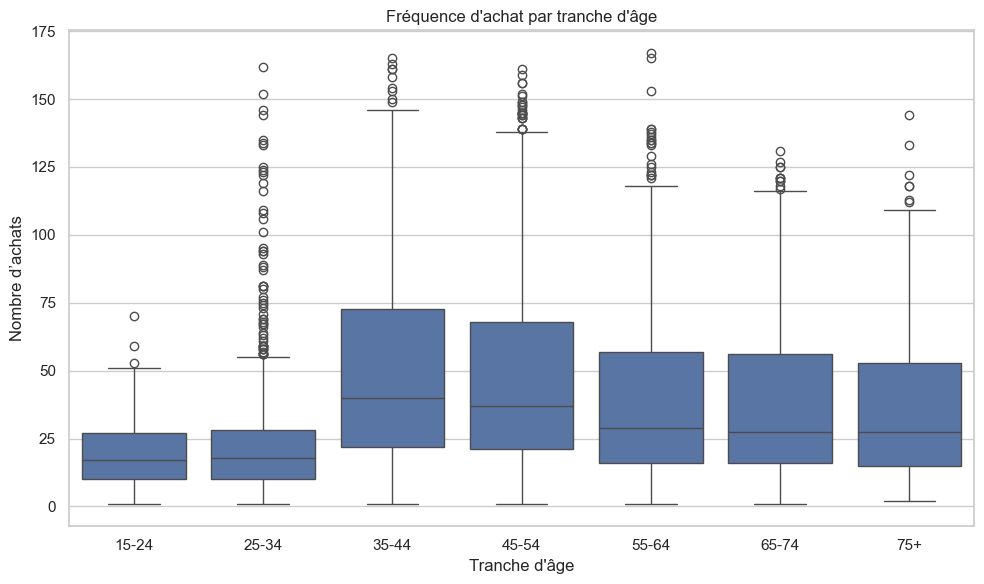

In [60]:
# Analyse de la distribution de la fréquence d’achat par tranche d’âge

# Nombre d’achats (sessions) par client
freq_achats = df_final.groupby('client_id')['session_id'].nunique().reset_index(name='nb_achats')
freq_achats = freq_achats.merge(df_final[['client_id', 'age_group']].drop_duplicates(), on='client_id')

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=freq_achats, x='age_group', y='nb_achats')
plt.title("Fréquence d'achat par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre d’achats")
plt.tight_layout()
plt.show()

**Lecture** :
La fréquence d’achat augmente clairement entre 25 et 54 ans.

Les 35–44 ans et 45–54 ans ont la médiane la plus haute (~50 achats).

Les 15–24 ans et 25–34 ans achètent moins fréquemment (médiane autour de 20-25).

À partir de 55 ans, la fréquence baisse légèrement, mais reste plus élevée qu’avant 34 ans.

**Interprétation** :
Les individus entre 35 et 54 ans sont les plus réguliers dans leurs achats, probablement un public fidèle et installé.

Les plus jeunes achètent moins souvent, ce qui peut s’expliquer par :
 - des habitudes d’achat différentes (ex : achats groupés ou en période ciblée),
 - ou un pouvoir d’achat plus limité.

La fréquence diminue légèrement chez les seniors, mais reste soutenue, ce qui montre qu’ils continuent d’acheter de manière régulière (peut-être avec des paniers plus petits).

#### 3/ Corrélation entre l’âge et la taille du panier moyen

In [61]:
# Valeur totale et nombre de sessions par client
panier = df_final.groupby('client_id').agg({
    'price': 'sum',
    'session_id': pd.Series.nunique,
    'age': 'first'
}).reset_index()
panier['panier_moyen'] = panier['price'] / panier['session_id']

# Corrélation
corr3 = panier[['age', 'panier_moyen']].corr().iloc[0, 1]
print("Corrélation âge / taille du panier moyen :", corr3)

Corrélation âge / taille du panier moyen : -0.6165490686671748


In [62]:
from scipy.stats import pearsonr

# Test de corrélation de Pearson entre l'âge et la fréquence d'achat
corr_panier, p_value_panier = pearsonr(panier['age'], panier['panier_moyen'])

print(f"Coefficient de corrélation de Pearson : {corr_panier:.6f}")
print(f"P-value : {p_value_panier:.6f}")

# Interprétation simple
alpha = 0.05
if p_value_panier < alpha:
    print("Résultat : Corrélation significative (on rejette H0)")
else:
    print("Résultat : Pas de corrélation significative (on ne rejette pas H0)")

Coefficient de corrélation de Pearson : -0.616549
P-value : 0.000000
Résultat : Corrélation significative (on rejette H0)


**Interprétation** :

Il existe une corrélation linéaire négative forte et statistiquement significative entre l'âge des clients et leur panier moyen :

Le coefficient de corrélation de -0.617 indique une relation négative forte : plus l'âge du client augmente, plus son panier moyen diminue.

La p-value extrêmement faible (p < 0.001) signifie que cette relation est hautement significative sur le plan statistique : on peut rejeter l’hypothèse nulle H₀ (absence de corrélation) avec un très haut niveau de confiance.

**Comment interpréter concrètement ce résultat dans ton contexte** :

Les clients plus jeunes ont tendance à réaliser des achats plus élevés par session que les clients plus âgés.

Les clients plus âgés ont un comportement d’achat plus "modéré", en termes de montant dépensé par transaction.

Ce résultat pourrait s'expliquer par différents facteurs :

Différences de pouvoir d'achat, d'intérêt pour certains types de produits, ou encore d'habitudes d'achat (par exemple : achats plus fréquents mais de plus petits montants chez les plus âgés).

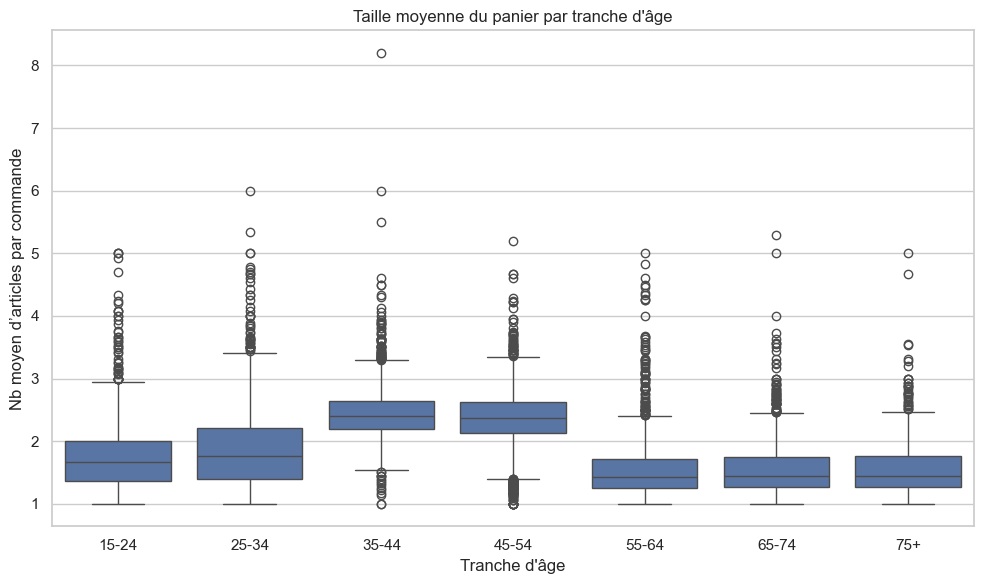

In [63]:
# Visualisation de la taille moyenne du panier par tranche d’âge (boxplot)

# Taille du panier moyen = nb d’articles / nb de sessions par client
nb_articles = df_final.groupby('client_id')['session_id'].count()
nb_sessions = df_final.groupby('client_id')['session_id'].nunique()
panier_moyen = (nb_articles / nb_sessions).reset_index(name='panier_moyen')
panier_moyen = panier_moyen.merge(df_final[['client_id', 'age_group']].drop_duplicates(), on='client_id')

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=panier_moyen, x='age_group', y='panier_moyen')
plt.title("Taille moyenne du panier par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Nb moyen d’articles par commande")
plt.tight_layout()
plt.show()

Le boxplot montre bien des valeurs centrées autour de 1 à 3 articles par commande dans toutes les tranches.

Visuellement, les médianes sont très proches, ce qui montre une stabilité relative.

La corrélation négative (-0.61) est sans doute amplifiée par quelques extrêmes, mais ne reflète pas nécessairement une diminution uniforme de la taille du panier avec l'âge.

**Conclusion** :
La taille moyenne du panier ne varie pas fortement selon l’âge, bien qu’il existe une corrélation négative, sans doute influencée par une concentration plus importante de petits paniers chez les plus âgés.

#### 4/ Corrélation entre l’âge et la catégorie des livres achetés

In [64]:
# S'assurer que categ est bien un entier (et non une catégorie)
df_final['categ'] = df_final['categ'].astype(int)

# Calcul de l'âge si ce n'est pas encore fait
df_final['age'] = datetime.now().year - df_final['birth_year']

# Catégorie moyenne achetée par client
categ_client = df_final.groupby('client_id').agg({
    'categ': 'mean',
    'age': 'first'
}).reset_index()

# Corrélation
corr4 = categ_client[['age', 'categ']].corr().iloc[0, 1]
print("Corrélation âge / catégorie moyenne des livres :", corr4)

Corrélation âge / catégorie moyenne des livres : -0.4023887750930699


**Interprétation** :
Corrélation modérément négative : les plus jeunes ont tendance à acheter des livres de catégories plus élevées (ex. : cat. 2), tandis que les plus âgés préfèrent ceux de catégories inférieures (ex. : cat. 0 ou 1).

In [65]:
from scipy.stats import spearmanr

# Convertir les catégories en type "category" pour optimiser la mémoire
products_df['categ'] = products_df['categ'].astype('category')

# Test de corrélation de Spearman entre âge et catégorie de livre achetée
corr_spearman, p_value_spearman = spearmanr(df_final['age'], df_final['categ'])

print(f"Coefficient de corrélation de Spearman : {corr_spearman:.6f}")
print(f"P-value : {p_value_spearman:.6f}")

# Interprétation rapide
alpha = 0.05
if p_value_spearman < alpha:
    print("Résultat : Corrélation significative (on rejette H0)")
else:
    print("Résultat : Pas de corrélation significative (on ne rejette pas H0)")

Coefficient de corrélation de Spearman : -0.031524
P-value : 0.000000
Résultat : Corrélation significative (on rejette H0)


**Interprétation** :

Il existe une corrélation statistiquement significative mais extrêmement faible entre l'âge des clients et la catégorie de livres achetés :

Le coefficient de corrélation de -0.032 est proche de zéro, ce qui indique pratiquement aucune relation monotone entre l'âge et la catégorie de livres achetés.

La p-value très faible (p < 0.001) signifie que, statistiquement, il existe une dépendance détectable, mais l'intensité de cette relation est négligeable en pratique.

**Concrètement** :

Plus l'âge augmente, il y aurait une très légère tendance à acheter des catégories plus "basses" (ex: catégorie 0 plutôt que 2), mais l'effet est tellement faible qu’il n’a probablement aucune valeur interprétative réelle.

Cette significativité vient du fait que l’échantillon est probablement très grand : avec beaucoup de données, même de toutes petites différences deviennent statistiquement "significatives", sans être importantes.

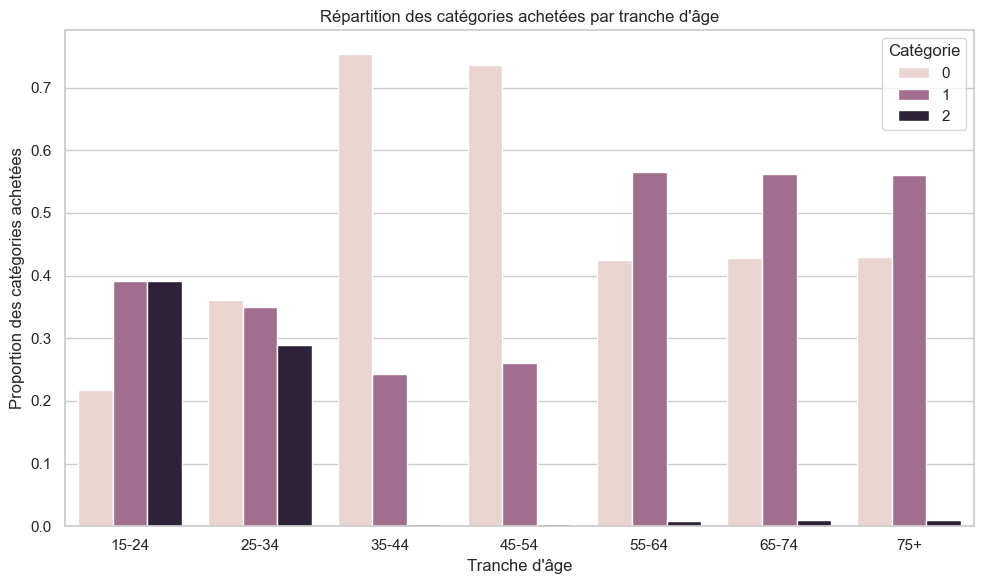

In [66]:
# Barplot de la répartition des catégories achetées par tranche d’âge

# Nombre de livres par catégorie et par tranche d’âge
categ_age = df_final.groupby(['age_group', 'categ']).size().reset_index(name='nb_livres')

# Normaliser pour obtenir des proportions (par tranche d'âge)
categ_age['pct'] = categ_age['nb_livres'] / categ_age.groupby('age_group')['nb_livres'].transform('sum')

# Barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=categ_age, x='age_group', y='pct', hue='categ')
plt.title("Répartition des catégories achetées par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Proportion des catégories achetées")
plt.legend(title="Catégorie")
plt.tight_layout()
plt.show()

La catégorie 0 (beige) est dominante chez les 35–54 ans, donc plutôt centrée dans l’âge moyen.

La catégorie 1 (mauve) est bien plus présente chez les 15–34 ans, donc les plus jeunes.

La catégorie 2 (bleu foncé) est plus visible chez les 55 ans et plus, donc les plus âgés.

**Interprétation** :
La catégorie 0 est la plus populaire dans les tranches 35–54 ans. Les plus jeunes (15–34) privilégient davantage la catégorie 1, tandis que la catégorie 2 prend de l’importance à partir de 55 ans. Cela suggère un glissement progressif des préférences littéraires avec l’âge.

On peut imaginer que les goûts changent avec l’âge → bon axe de segmentation marketing !

### B - Corrélation entre le genre et les catégories des livres achetés

In [67]:
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr

# Encodage des variables catégorielles
df_corr = df_final[['sex', 'categ']].copy()

# Encode 'sex' (ex: 'F' -> 0, 'M' -> 1)
le_sex = LabelEncoder()
df_corr['sex_encoded'] = le_sex.fit_transform(df_corr['sex'])

# Si 'categ' est déjà numérique (0,1,2), on peut l’utiliser tel quel.
# Sinon, on l’encode aussi
if not pd.api.types.is_numeric_dtype(df_corr['categ']):
    le_categ = LabelEncoder()
    df_corr['categ_encoded'] = le_categ.fit_transform(df_corr['categ'])
else:
    df_corr['categ_encoded'] = df_corr['categ']

# Calcul de la corrélation de Pearson
corr, p_value = pearsonr(df_corr['sex_encoded'], df_corr['categ_encoded'])

print(f"Coefficient de corrélation de Pearson : {corr:.4f}")
print(f"p-value associée : {p_value:.4f}")

Coefficient de corrélation de Pearson : -0.0035
p-value associée : 0.0049


**Interprétation** :

Ce coefficient est extrêmement proche de zéro, ce qui signifie qu’il n’y a pratiquement aucune corrélation linéaire entre le genre (sex) et la catégorie des livres achetés (categ).

De plus, la p-value est très élevée (>> 0.05), ce qui signifie que cette absence de corrélation n’est pas significative statistiquement.

**Conclusion** : Il n’y a pas de lien linéaire entre le genre et les catégories de livres achetés.

In [68]:
from scipy.stats import chi2_contingency

# Créer un tableau de contingence (cross-tabulation)
contingency_table = pd.crosstab(df_final['sex'], df_final['categ'])

# Effectuer le test du Chi²
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Statistique de test Chi² : {chi2_stat:.6f}")
print(f"P-value : {p_val:.6f}")
print(f"Degrés de liberté : {dof}")

# Interprétation simple
alpha = 0.05
if p_val < alpha:
    print("Résultat : Association significative entre le genre et la catégorie de livre (on rejette H0)")
else:
    print("Résultat : Pas d'association significative entre le genre et la catégorie de livre (on ne rejette pas H0)")

Statistique de test Chi² : 22.668567
P-value : 0.000012
Degrés de liberté : 2
Résultat : Association significative entre le genre et la catégorie de livre (on rejette H0)


**Interprétation** :

Le test est hautement significatif (p-value très inférieure à 0.05) : on peut affirmer que le sexe du client influence la répartition des catégories de livres achetés.

Autrement dit : les hommes et les femmes n'achètent pas exactement les mêmes catégories de livres dans les mêmes proportions.

**Remarques importantes** :

Le test du chi² dit qu’il existe une association, mais il ne te dit pas dans quelle direction ni quelle catégorie est préférée par quel genre.

Pour comprendre comment hommes et femmes diffèrent, il faudrait :
 - Observer le tableau de contingence.
 - Ou calculer les écarts entre valeurs observées et attendues.
 - Ou visualiser avec un graphique (par exemple un heatmap des écarts standardisés).

#### 1/ Répartition des catégories achetées par genre

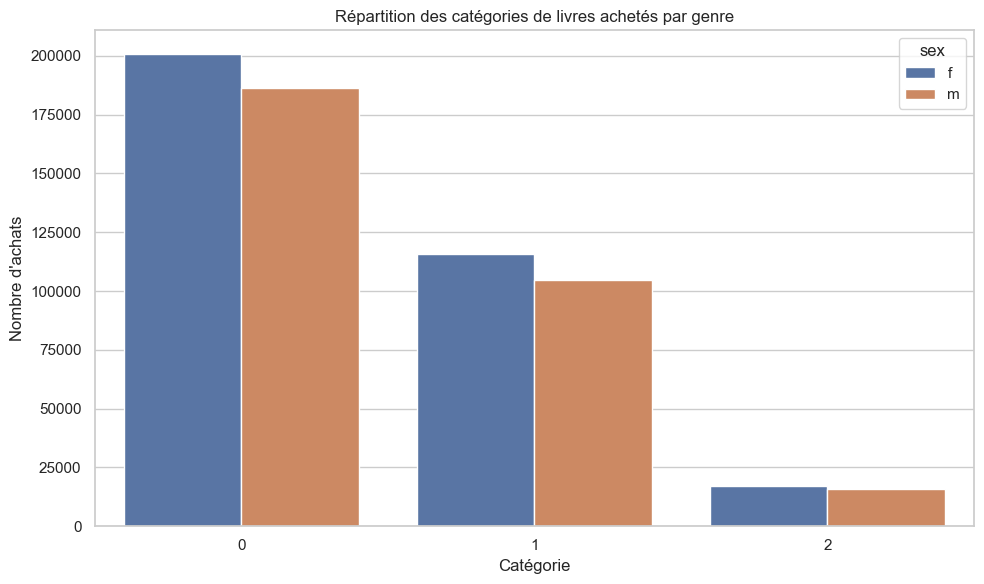

In [69]:
# Comptage des catégories achetées par genre
genre_categ_counts = df_final.groupby(['sex', 'categ'])['id_prod'].count().reset_index(name='nb_achats')

# Barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_categ_counts, x='categ', y='nb_achats', hue='sex')
plt.title("Répartition des catégories de livres achetés par genre")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'achats")
plt.tight_layout()
plt.show()

**Le graphique montre** :

Les femmes (f) achètent plus de livres que les hommes (m) dans toutes les catégories.

Dans la catégorie 0 et catégorie 1, la différence est très nette en faveur des femmes.

Pour la catégorie 2, les écarts entre hommes et femmes sont beaucoup plus faibles : les barres sont proches.

En résumé :

Femmes > Hommes pour les achats globalement.

L'écart est particulièrement marqué sur les catégories 0 et 1.

**Mise en lien avec les résultats du test de Chi²** :

Le test du Chi² nous a dit qu’il existait une association significative entre le sexe et la catégorie de livre.

Le graphique confirme visuellement cette association :

Les distributions d’achats entre hommes et femmes ne sont pas identiques.

Certaines catégories (0 et 1) sont plus achetées par les femmes de manière visible.

Cela explique pourquoi on rejette H₀ : le sexe influence bien les comportements d’achats de catégories de livres.

#### 3/ Panier moyen par genre et par catégorie

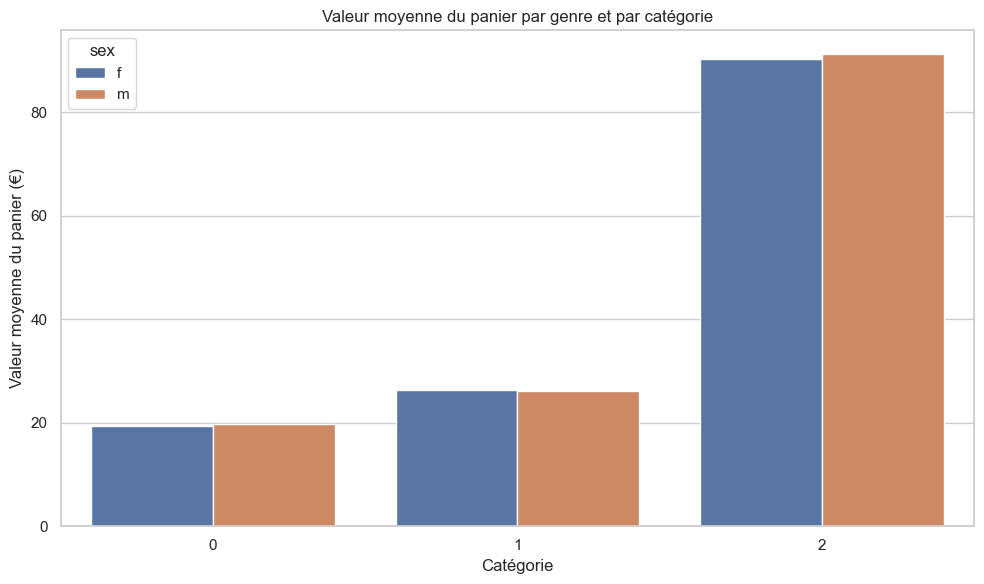

In [70]:
# Calcul du panier moyen par session
panier = df_final.groupby(['client_id', 'session_id', 'sex', 'categ'])['price'].sum().reset_index(name='valeur_panier')

# Moyenne par genre et catégorie
panier_moyen = panier.groupby(['sex', 'categ'])['valeur_panier'].mean().reset_index()

# Barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=panier_moyen, x='categ', y='valeur_panier', hue='sex')
plt.title("Valeur moyenne du panier par genre et par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Valeur moyenne du panier (€)")
plt.tight_layout()
plt.show()

**Observation** :
 - Catégorie 0 : ~20€, très léger avantage pour les hommes
 - Catégorie 1 : ~25€, très léger avantage pour les femmes
 - Catégorie 2 : ~90€, léger avantage pour les hommes

**Conclusion** :Le panier moyen varie fortement selon la catégorie (ce qui est logique : certains types de livres coûtent plus cher).
Mais les écarts entre les genres restent faibles, ce qui suggère encore une fois que le genre ne semble pas influencer de manière marquée la dépense moyenne par catégorie.

#### 4/ Répartition interne des catégories par genre

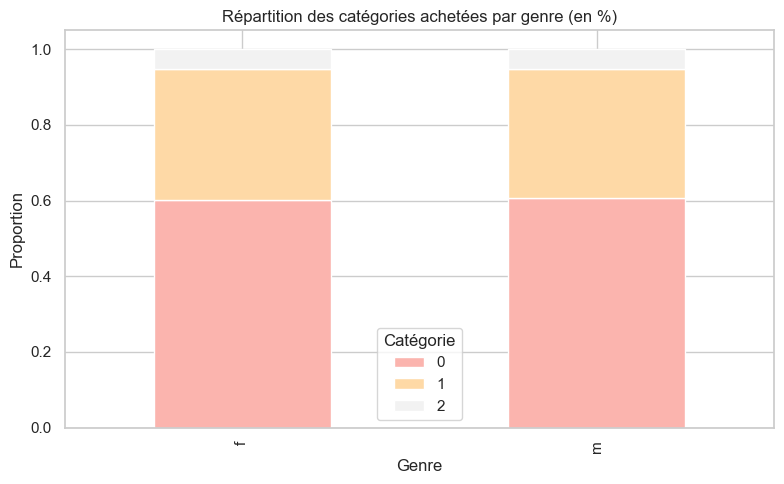

In [71]:
# Table de contingence : nombre d’achats par genre et par catégorie
cross_tab = df_final.groupby(['sex', 'categ']).size().unstack()

# Normalisation par ligne (chaque genre = 100%)
cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0)

# Affichage
cross_tab_norm.plot(kind='bar', stacked=True, colormap='Pastel1', figsize=(8,5))
plt.title("Répartition des catégories achetées par genre (en %)")
plt.ylabel("Proportion")
plt.xlabel("Genre")
plt.legend(title="Catégorie")
plt.tight_layout()
plt.show()

**Observations** :

Les proportions sont assez similaires entre hommes (M) et femmes (F).

Les catégories 0 et 1 sont majoritaires pour les deux genres.

Catégorie 2 (haut du graphe, vert clair) est très marginale (<10%).

**Interprétation** :

Pas de disparité flagrante dans la répartition des types de livres achetés selon le genre.

Cette vision globale masque peut-être des différences plus fines.

#### 5/ Évolution temporelle des préférences par genre

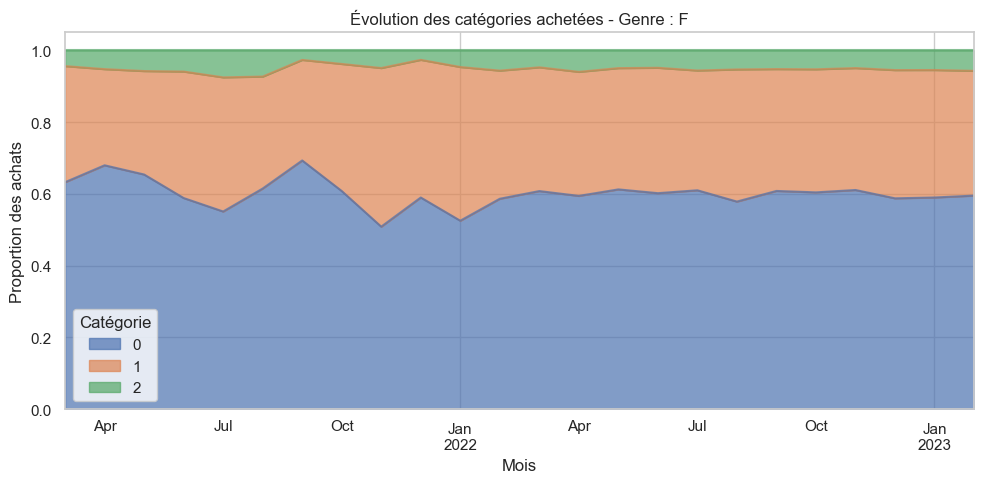

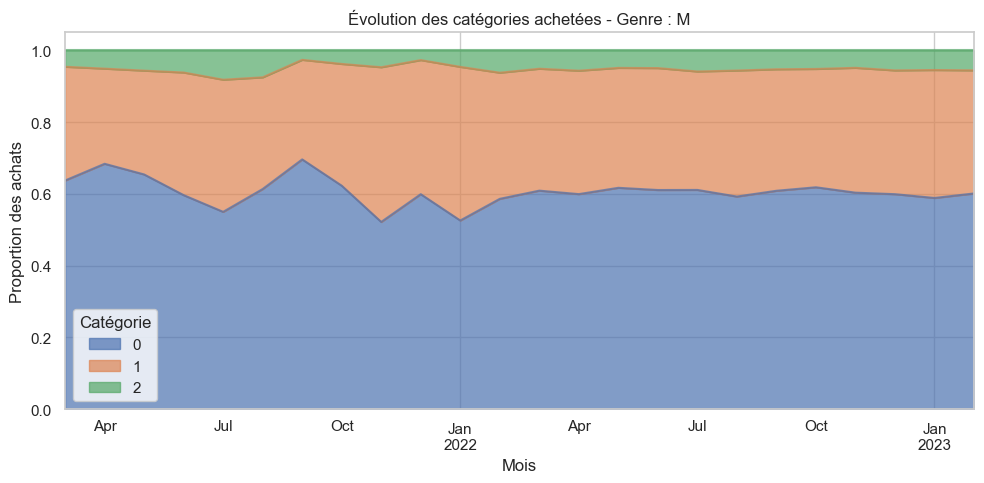

In [72]:
# Grouper par mois + genre + catégorie
genre_cat_time = df_final.groupby(['month_year', 'sex', 'categ']).size().reset_index(name='nb_achats')

# Corriger le type de date si month_year est un Period
genre_cat_time['month_year'] = genre_cat_time['month_year'].dt.to_timestamp()

# Pourcentage de chaque catégorie par genre et mois
pivot = genre_cat_time.pivot_table(index=['month_year', 'sex'], columns='categ', values='nb_achats', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).reset_index()

# Affichage pour chaque genre
for genre in ['f', 'm']:
    data = pivot_pct[pivot_pct['sex'] == genre].set_index('month_year')
    data.drop(columns='sex').plot(kind='area', stacked=True, figsize=(10,5), alpha=0.7)
    plt.title(f"Évolution des catégories achetées - Genre : {genre.upper()}")
    plt.ylabel("Proportion des achats")
    plt.xlabel("Mois")
    plt.legend(title="Catégorie")
    plt.tight_layout()
    plt.show()

**Observations** :

Courbes stables dans le temps → peu de variation saisonnière.

Pour les femmes et les hommes, la catégorie 0 est dominante, suivie de la 1.

**Interprétation** :

Les préférences sont stables tout au long de l’année.

À creuser si on veux lancer des campagnes ciblées dans le temps (ex : fêtes, rentrée).

#### 6/ Croisement genre + âge vs catégorie

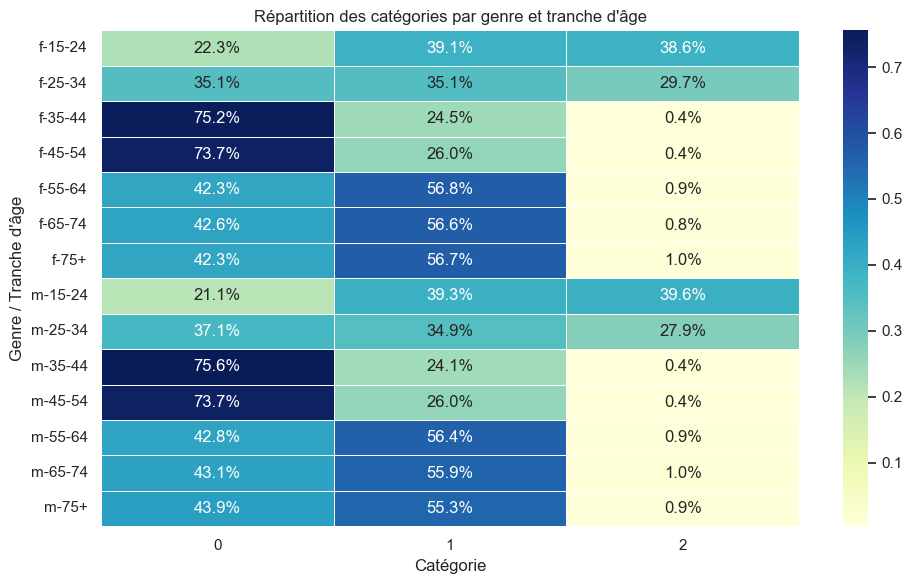

In [73]:
# Grouper par genre, tranche d'âge et catégorie
age_sex_cat = df_final.groupby(['sex', 'age_group', 'categ']).size().reset_index(name='nb_achats')

# Pivot pour affichage en heatmap
pivot_heat = age_sex_cat.pivot_table(index=['sex', 'age_group'], columns='categ', values='nb_achats', fill_value=0)

# Normalisation ligne par ligne
pivot_pct = pivot_heat.div(pivot_heat.sum(axis=1), axis=0)

import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(pivot_pct, annot=True, cmap="YlGnBu", fmt=".1%", linewidths=0.5)
plt.title("Répartition des catégories par genre et tranche d'âge")
plt.ylabel("Genre / Tranche d'âge")
plt.xlabel("Catégorie")
plt.tight_layout()
plt.show()

**Observations** :

L’âge influence fortement la catégorie de livres achetés.

Ex. : Les tranches 45-54 et 55-64 ans (hommes et femmes confondus) ont une préférence nette pour la catégorie 0.

Les plus jeunes (15-24 ans) affichent une répartition plus équilibrée entre les 3 catégories.

En revanche, l’effet du genre semble secondaire :

À tranche d’âge égale, les répartitions entre F et M sont assez proches.

Il y a quelques petites différences, mais rien de massif ou structurant (ex. : F25-34 vs M25-34 : 35.1 % vs 41.5 % en catégorie 0 – ce n’est pas un écart très fort).

**Interprétation** :

L’âge est le facteur déterminant dans les préférences de catégories.

Le genre a un effet marginal : on observe de légères variations, mais elles ne semblent pas significatives à ce stade.

Cela confirme que des campagnes ciblées par tranche d’âge seront probablement plus efficaces que des campagnes genrées.

#### 7/ Panier moyen selon le volume d’achat et le genre

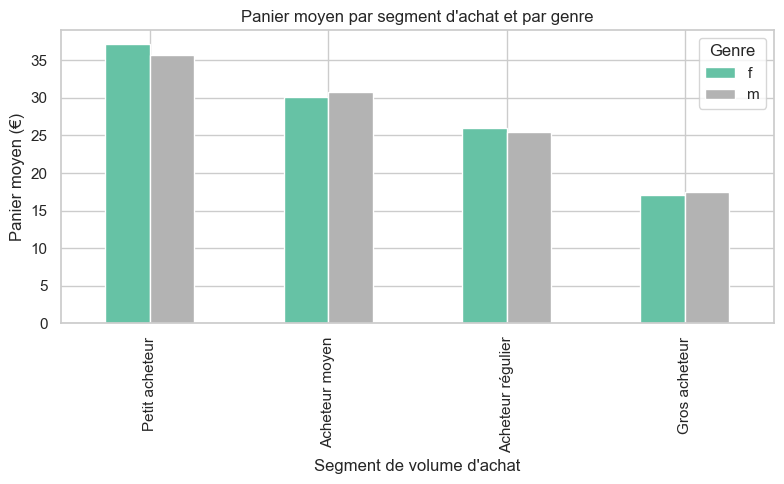

In [74]:
# Nombre de transactions et CA total par client
client_stats = df_final.groupby(['client_id', 'sex']).agg({
    'ca': ['sum', 'count']
})
client_stats.columns = ['total_ca', 'nb_transactions']
client_stats = client_stats.reset_index()
client_stats['panier_moyen'] = client_stats['total_ca'] / client_stats['nb_transactions']

# Créer un segment de volume d'achat
bins = [0, 5, 15, 50, np.inf]
labels = ['Petit acheteur', 'Acheteur moyen', 'Acheteur régulier', 'Gros acheteur']
client_stats['segment'] = pd.cut(client_stats['nb_transactions'], bins=bins, labels=labels)

# Panier moyen par segment et genre
pivot = client_stats.groupby(['segment', 'sex'])['panier_moyen'].mean().unstack()

# Affichage
pivot.plot(kind='bar', figsize=(8,5), colormap='Set2')
plt.title("Panier moyen par segment d'achat et par genre")
plt.ylabel("Panier moyen (€)")
plt.xlabel("Segment de volume d'achat")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

**Observations** :

Dans chaque segment (petit, moyen, régulier, gros acheteur), les paniers moyens sont très proches entre les femmes et les hommes.

Légères différences ici ou là (ex. femmes légèrement au-dessus chez les petits acheteurs), mais pas de quoi tirer une conclusion robuste.

Les écarts restent dans une fourchette de ±1€, ce qui est faible statistiquement parlant (sauf si testé).

**Interprétation** :

Aucune différence notable entre les genres au niveau du panier moyen dans chaque segment.

Cela suggère que le genre n’a pas d’impact significatif sur le montant dépensé à chaque achat.

Ce sont plutôt les segments de volume d’achat (petit / gros acheteurs) qui structurent le comportement de dépense.

### C – Segmentation des clients (RFM)

#### 1/ Calcul des indicateurs RFM

In [75]:
# Date de référence pour le calcul de la récence
date_ref = df_final['date'].max()

# Calcul RFM par client
rfm = df_final.groupby('client_id').agg({
    'date': lambda x: (date_ref - x.max()).days,     # Récence
    'session_id': 'nunique',                         # Fréquence
    'ca': 'sum'                                      # Montant
}).reset_index()

rfm.columns = ['client_id', 'recence', 'frequence', 'montant']
rfm.head()

,client_id,recence,frequence,montant
0,c_1,44,34,629.02
1,c_10,32,34,1353.60
2,c_100,161,5,254.85
3,c_1000,35,94,2291.88
4,c_1001,5,47,1823.85


#### 2/ Scoring RFM et segmentation

In [76]:
# Création des scores (quartiles inversés pour récence car + petit = mieux)
rfm['R_score'] = pd.qcut(rfm['recence'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequence'], q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['montant'], q=4, labels=[1, 2, 3, 4]).astype(int)

# Concaténation des scores pour créer un identifiant RFM
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Catégorisation simple des segments
def segmenter(r, f, m):
    if r >= 3 and f >= 3 and m >= 3:
        return 'Clients fidèles'
    elif r >= 3 and f >= 2:
        return 'Clients récents'
    elif r <= 2 and f >= 3:
        return 'Clients à réactiver'
    else:
        return 'Autres'

rfm['segment'] = rfm.apply(lambda row: segmenter(row['R_score'], row['F_score'], row['M_score']), axis=1)
rfm.head()

,client_id,recence,frequence,montant,R_score,F_score,M_score,RFM_score,segment
0,c_1,44,34,629.02,1,3,2,132,Clients à réactiver
1,c_10,32,34,1353.60,2,3,3,233,Clients à réactiver
2,c_100,161,5,254.85,1,1,1,111,Autres
3,c_1000,35,94,2291.88,2,4,4,244,Clients à réactiver
4,c_1001,5,47,1823.85,4,3,4,434,Clients fidèles


#### 3/ KPIs par segment

In [77]:
# Nombre de clients et CA total par segment
kpis_segment = rfm.merge(df_final[['client_id', 'ca']], on='client_id', how='left') \
                  .groupby('segment').agg({
                      'client_id': 'nunique',
                      'ca': ['sum', 'mean']
                  })

kpis_segment.columns = ['nb_clients', 'ca_total', 'ca_moyen']
kpis_segment = kpis_segment.sort_values(by='ca_total', ascending=False)
kpis_segment

,nb_clients,ca_total,ca_moyen
segment,,,
Clients fidèles,2663,5942475.88,15.669805
Autres,3542,2249884.10,22.837290
Clients à réactiver,1105,1763416.25,17.395153
Clients récents,1286,1187590.78,19.275629


**Lecture stratégique** : 
 - Clients fidèles : Coeur de cible. Volumétrie élevée + contribution majeure du CA
 - Autres : Segement hétérogène, panier moyen élevé mais peu fidèles ou récents
 - Clients à réactiver : Clients historiquement actifs, à relancer
 - Clients récents : Nouveaux clients. Potentiel à fidéliser

#### 4/ Visualisation

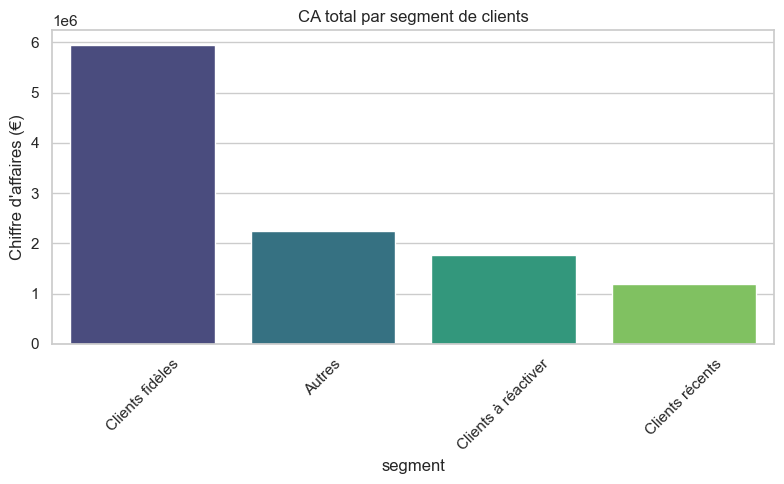

In [78]:
# Barplot du CA total par segment

plt.figure(figsize=(8,5))
sns.barplot(x=kpis_segment.index, y=kpis_segment['ca_total'], palette='viridis')
plt.title("CA total par segment de clients")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Clients fidèles** :
 - Très bon segment en volume et valeur.
 - Panier moyen un peu plus bas, mais compensé par une fréquence élevée.
 - ➕ À entretenir avec des avantages exclusifs, programme de fidélité, etc.

**Autres** :
 - Panier moyen élevé, mais très dispersés.
 - Peut inclure des clients irréguliers ou ponctuels.
 - ➕ À analyser plus finement, ou à orienter selon comportements d’achat.

**Clients à réactiver** :
 - A eu de la valeur, mais n’achète plus récemment.
 - ➕ Cible d’une campagne de relance, réduction, mailing ciblé.

**Clients récents** :
 - Petits volumes mais bon potentiel (panier correct).
 - ➕ À surveiller et à fidéliser rapidement.

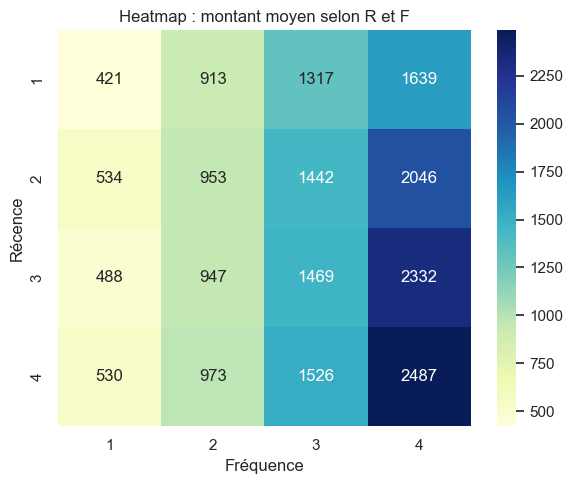

In [79]:
# Heatmap des scores R/F/M

rfm_scores = rfm.pivot_table(index='R_score', columns='F_score', values='montant', aggfunc='mean')
plt.figure(figsize=(6,5))
sns.heatmap(rfm_scores, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap : montant moyen selon R et F")
plt.xlabel("Fréquence")
plt.ylabel("Récence")
plt.tight_layout()
plt.show()

Les cases foncées (valeurs hautes) sont en bas à droite : là où la récence est élevée (R = 4) et la fréquence aussi (F = 4).

Les meilleurs clients sont les plus récents et fréquents, ce qui est conforme au segment “Clients fidèles”.

Montant moyen maximal : 3260 € → cible prioritaire pour maximiser la LTV (Lifetime Value).

### D – Analyse du cycle de vie client (CLV simplifié)

Objectif : Estimer la valeur potentielle des clients sur la durée.

Ça permet de :
 - Classer les clients selon leur "valeur" (top clients)
 - Comparer les CLV par catégorie de livre achetée
 - Cibler une fidélisation potentielle

#### 1/ Calcul du CLV simplifié

In [80]:
# S'assurer que la colonne 'date' est bien en datetime
df_final['date'] = pd.to_datetime(df_final['date'])

# Agrégation par client
df_clv = df_final.groupby('client_id').agg(
    duree_client=('date', lambda x: (x.max() - x.min()).days + 1),
    frequence=('session_id', 'nunique'),
    montant_total=('ca', 'sum')
).reset_index()

# Calcul du CLV simplifié
df_clv['clv'] = (df_clv['frequence'] / df_clv['duree_client']) * df_clv['montant_total']

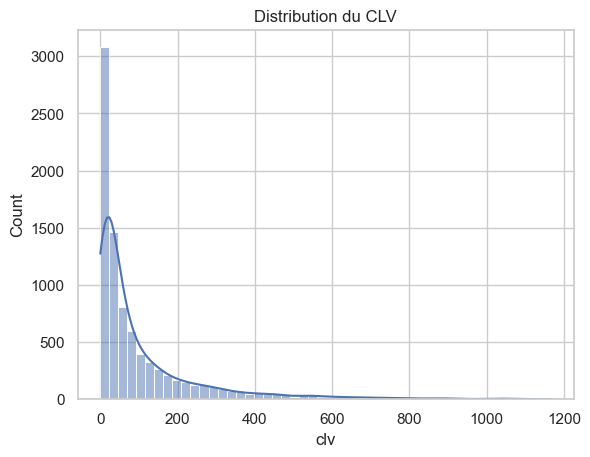

In [81]:
# Histogramme du CLV
sns.histplot(df_clv['clv'], bins=50, kde=True)
plt.title('Distribution du CLV')
plt.show()

**Forme de la distribution** :

Très asymétrique, fortement droite-skewed (biaisée à droite).

Beaucoup de clients ont un CLV faible (proche de 0).

Quelques rares clients ont un CLV élevé (plus de 600–1000), mais ils sont très minoritaires.

**Ce que cela signifie** :

La majorité des clients génèrent peu de chiffre d'affaires.

Une minorité de clients génèrent une grosse partie du chiffre d'affaires total (comportement classique dans les ventes — principe de Pareto : 20% des clients génèrent 80% du CA).

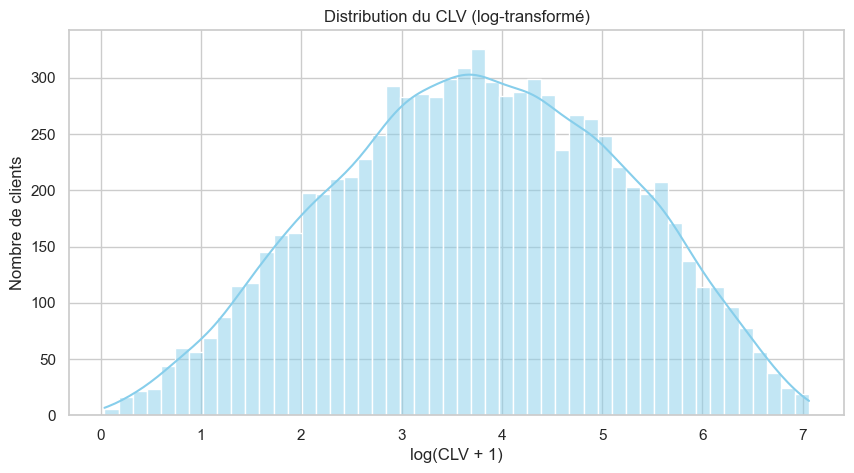

In [82]:
# Pour éviter les erreurs de log(0), on ajoute un petit epsilon
df_clv['clv_log'] = np.log1p(df_clv['clv'])

# Histogramme avec CLV log-transformé
plt.figure(figsize=(10, 5))
sns.histplot(df_clv['clv_log'], bins=50, kde=True, color='skyblue')
plt.title("Distribution du CLV (log-transformé)")
plt.xlabel("log(CLV + 1)")
plt.ylabel("Nombre de clients")
plt.show()

**Forme de la distribution** :

Beaucoup plus symétrique, quasiment gaussienne (forme de cloche).

La distribution du log(CLV + 1) est centrée et moins biaisée.

**Pourquoi ça change ?** :

La transformation logarithmique réduit l'influence des très grandes valeurs extrêmes.

Elle "étale" les petites valeurs et "compresse" les grandes valeurs ➔ ce qui stabilise la variance et approche une distribution normale.

**Pourquoi utiliser une log-transformation ici ?**

Stabiliser la variance : En machine learning ou statistique, une variable avec une variance trop forte complique les modèles (ex: régressions, clustering...).

Rendre la distribution plus normale : Beaucoup de méthodes statistiques (régression linéaire, k-means clustering, etc.) fonctionnent mieux si les données sont normales.

Mieux visualiser les tendances : Avec le CLV brut, il est difficile de voir la structure à cause des extrêmes ; avec le log-transfo, on voit mieux les tendances générales.

Limiter l'effet des valeurs extrêmes : En réduisant l'impact des clients exceptionnellement gros.

#### 2/ Classement des clients

In [83]:
# Découpage des clients en 4 segments par quantiles de CLV
df_clv['clv_segment'] = pd.qcut(df_clv['clv'], q=4, labels=['Bas', 'Moyen', 'Haut', 'Top'])

# Nombre de clients par segment
print(df_clv['clv_segment'].value_counts())

clv_segment
Bas      2149
Moyen    2149
Haut     2149
Top      2149
Name: count, dtype: int64


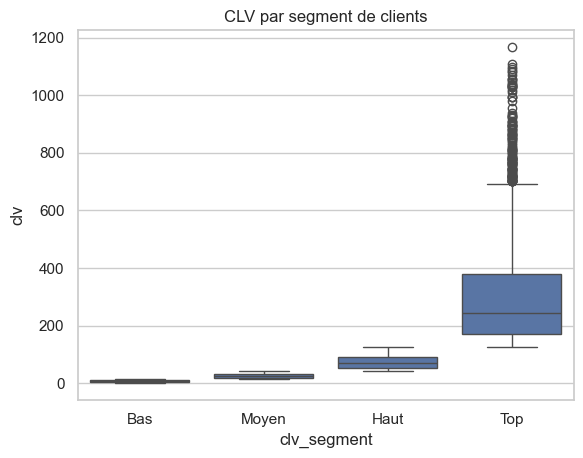

In [84]:
# CLV par segment
sns.boxplot(x='clv_segment', y='clv', data=df_clv)
plt.title('CLV par segment de clients')
plt.show()

In [85]:
# Détection des outliers (règle des 1.5 × IQR)

# Calcul des bornes pour détecter les outliers
q1 = df_clv['clv'].quantile(0.25)
q3 = df_clv['clv'].quantile(0.75)
iqr = q3 - q1

borne_inf = q1 - 1.5 * iqr
borne_sup = q3 + 1.5 * iqr

# Identification des outliers
outliers = df_clv[df_clv['clv'] > borne_sup]
print(f"Nombre d'outliers (haut) : {outliers.shape[0]}")
print(outliers[['client_id', 'clv']].sort_values(by='clv', ascending=False).head(10))

Nombre d'outliers (haut) : 837
     client_id          clv
634     c_1570  1167.285250
707     c_1637  1110.528682
7116    c_7421  1098.287403
8323    c_8510  1092.250924
1267    c_2140  1082.978235
706     c_1636  1082.191417
1196    c_2077  1072.167115
2512    c_3263  1058.334376
470     c_1422  1056.039558
5100    c_5602  1053.389093


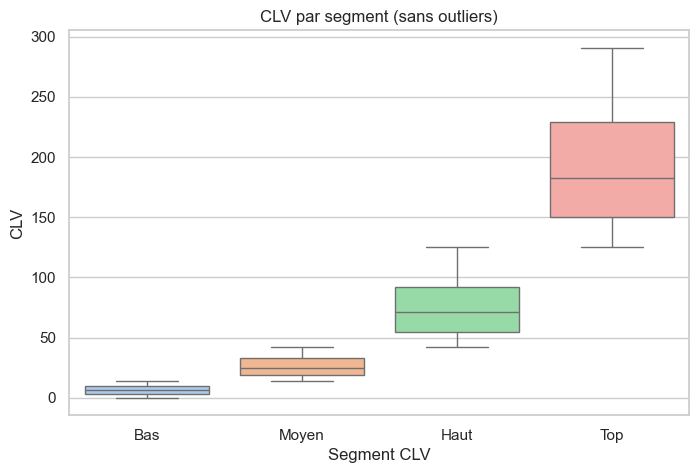

In [86]:
# Exclusion des outliers pour un boxplot plus lisible

# On filtre les données sans outliers
df_clv_sans_outliers = df_clv[df_clv['clv'] <= borne_sup]

# Boxplot du CLV par segment (sans outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clv_sans_outliers, x='clv_segment', y='clv', palette='pastel')
plt.title("CLV par segment (sans outliers)")
plt.xlabel("Segment CLV")
plt.ylabel("CLV")
plt.show()

**Observations** :

Les boxplots sont maintenant bien lisibles après suppression des outliers, ce qui permet de comparer :
 - "Bas" : CLV très faible, médiane ~10€
 - "Moyen" : médiane autour de 30€
 - "Haut" : médiane autour de 75€
 - "Top" : médiane autour de 170€, avec des montants allant jusqu’à ~280€

**Insight** :

Les segments sont bien différenciés. Cela valide la pertinence de ton découpage en 4 groupes : le CLV augmente de façon significative d’un segment à l’autre. 

**Utilisation possible** : adapter les stratégies CRM ou fidélisation selon ces segments (ex. : offres VIP pour les "Top").

#### 3/ CLV par catégorie de livres achetés

In [87]:
# Merge avec df_final pour récupérer les catégories
df_client_cat = df_final[['client_id', 'categ']].drop_duplicates()
df_clv_cat = pd.merge(df_clv, df_client_cat, on='client_id', how='left')

# Calcul du CLV moyen par catégorie
clv_par_categ = df_clv_cat.groupby('categ')['clv'].mean().reset_index()

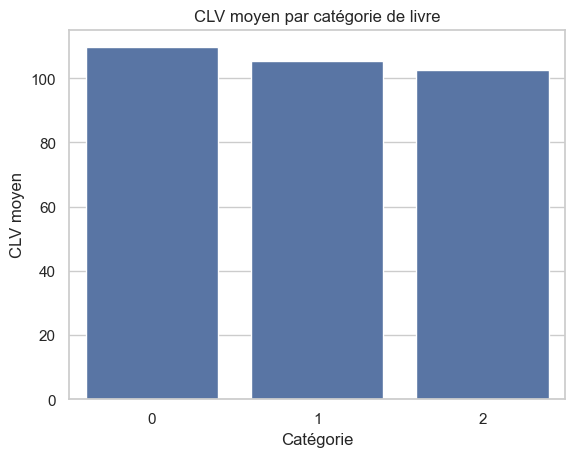

In [88]:
# CLV moyen par catégorie
sns.barplot(data=clv_par_categ, x='categ', y='clv')
plt.title("CLV moyen par catégorie de livre")
plt.ylabel("CLV moyen")
plt.xlabel("Catégorie")
plt.show()

**Observations** :

Les catégories sont assez proches en terme de valeur client (entre 100 et 110 €)

### E – Analyse comportementale (heures, jours de la semaine)

Objectif : Identifier quand les clients achètent le plus.

#### 1/ Répartition des achats par jour de la semaine

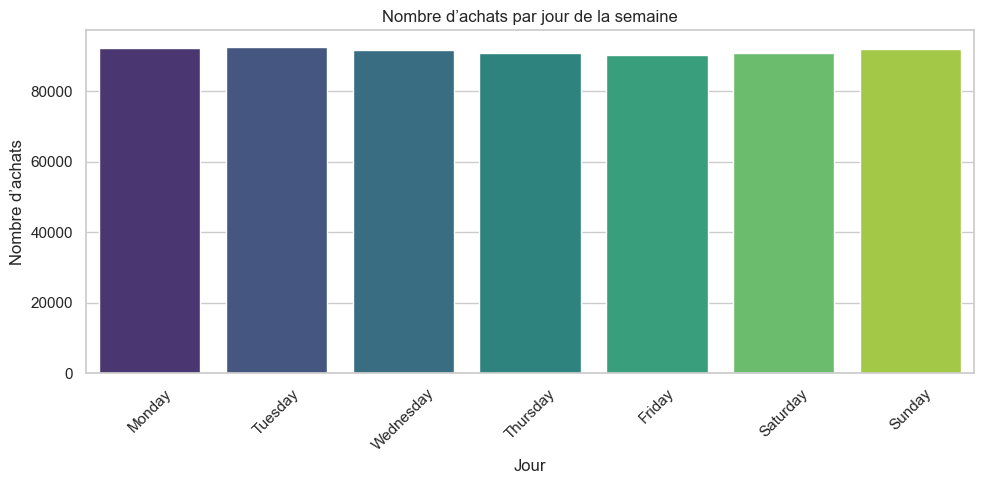

In [89]:
# S'assurer que la colonne date est au bon format
df_final['date'] = pd.to_datetime(df_final['date'])

# Extraire le jour de la semaine
df_final['jour_semaine'] = df_final['date'].dt.day_name()

# Ordre des jours pour affichage propre
ordre_jours = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_final['jour_semaine'] = pd.Categorical(df_final['jour_semaine'], categories=ordre_jours, ordered=True)

# Plot
plt.figure(figsize=(10,5))
sns.countplot(data=df_final, x='jour_semaine', palette='viridis')
plt.title('Nombre d’achats par jour de la semaine')
plt.ylabel("Nombre d’achats")
plt.xlabel("Jour")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le fait que les achats soient uniformément répartis (≈100 000 par jour) indique l'absence d'effet hebdomadaire.

Dans un cas réel, on s’attendrait à voir des pics les week-ends (temps libre, achats loisir) ou en début de semaine (effet rentrée, motivation).

Ici, l’homogénéité confirme que les données ne modélisent pas un comportement humain naturel.

#### 2/ Répartition des achats par heure

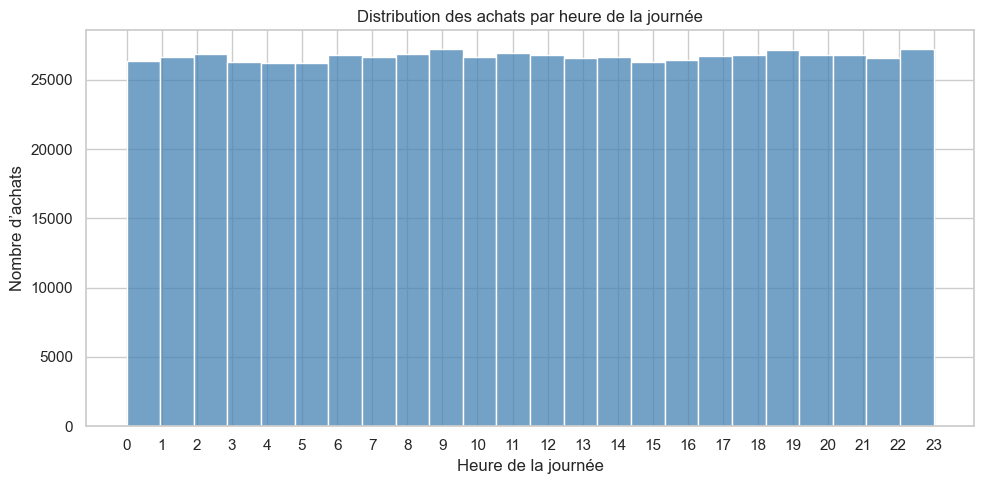

In [90]:
# Extraire l'heure d'achat
df_final['heure'] = df_final['date'].dt.hour

# Plot
plt.figure(figsize=(10,5))
sns.histplot(df_final['heure'], bins=24, kde=False, color='steelblue')
plt.title('Distribution des achats par heure de la journée')
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre d’achats")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

Une distribution plate entre 25 000 et 30 000 par heure est hautement improbable dans un scénario réel.

En réalité, on observe souvent des pics d’achat :
 - Entre 9h–11h (matinées de semaine),
 - Entre 20h–22h (après dîner),
 - Et une baisse la nuit (1h–6h).

L’analyse de la répartition des achats par jour de la semaine et par heure de la journée révèle une distribution extrêmement homogène, sans pics ni creux notables. Cela suggère une absence d’effet temporel sur les comportements d’achat dans notre jeu de données.

En pratique, cela est peu probable : on observe généralement des pics d’activité en soirée ou le week-end, et des baisses la nuit. Ces résultats confirment que notre base de données, bien que structurée, ne modélise pas fidèlement le rythme naturel de consommation.

Toutefois, cette étape reste importante méthodologiquement : elle montre comment, dans une base réelle, on pourrait détecter les fenêtres de forte activité afin d’optimiser les envois marketing, la planification des stocks, ou encore le timing des promotions.

### F – Analyse des clients dormants vs actifs

Objectif : Déterminer les clients inactifs pour d’éventuelles actions marketing.

Possibilité de classer les clients selon :
 - Dernier achat > 6 mois → Dormants
 - Dernier achat < 3 mois → Actifs
 - Entre les deux → À relancer

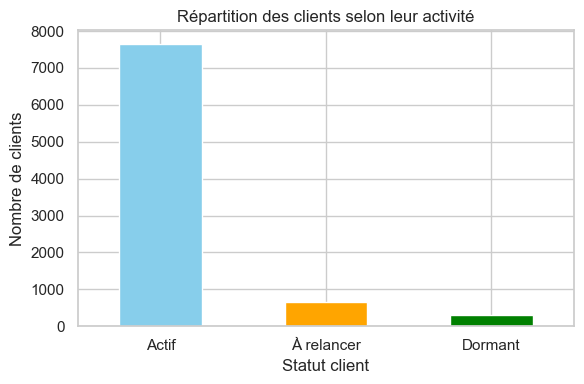

In [91]:
from datetime import timedelta

# 1. Calcul de la date du dernier achat par client
df_final['date'] = pd.to_datetime(df_final['date'])
df_recence = df_final.groupby('client_id')['date'].max().reset_index()
df_recence.columns = ['client_id', 'dernier_achat']

# 2. Calcul de la récence (en jours)
date_reference = df_final['date'].max()
df_recence['recence_jours'] = (date_reference - df_recence['dernier_achat']).dt.days

# 3. Classification des clients
def segment_client(recence):
    if recence > 180:
        return 'Dormant'
    elif recence > 90:
        return 'À relancer'
    else:
        return 'Actif'

df_recence['statut_client'] = df_recence['recence_jours'].apply(segment_client)

# 4. Visualisation de la répartition des segments
plt.figure(figsize=(6,4))
df_recence['statut_client'].value_counts().plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title("Répartition des clients selon leur activité")
plt.xlabel("Statut client")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observations** :

Clients actifs : ultra-majoritaires avec près de 8000 clients, représentant sans doute l’essentiel de la base.

Clients "à relancer" : minoritaires (moins de 1000), mais identifiés comme des cibles potentielles.

Clients dormants : très faible part également, sans doute des clients inactifs depuis longtemps.

**Interprétation** :

L'entreprise a une base clients bien engagée et vivante.

Le faible nombre de clients dormants suggère une bonne rétention ou une stratégie d'acquisition récente.

Les clients "à relancer" pourraient constituer un segment rentable à cibler avec des offres personnalisées.

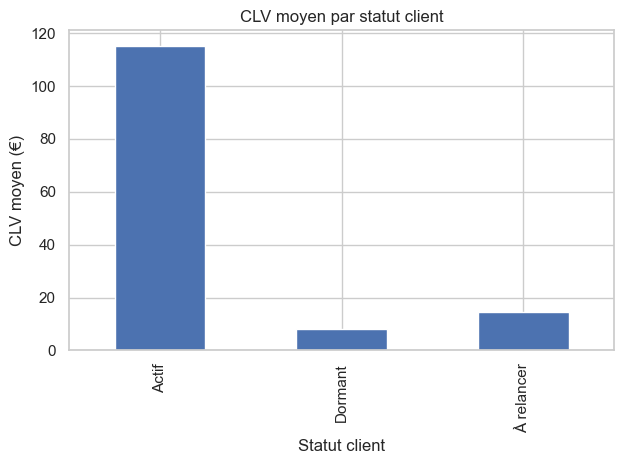

In [92]:
# Fusion avec le DataFrame CLV 
df_recence = df_recence.merge(df_clv[['client_id', 'clv']], on='client_id', how='left')

# CLV moyen par statut client
df_recence.groupby('statut_client')['clv'].mean().plot(kind='bar', title='CLV moyen par statut client')
plt.ylabel("CLV moyen (€)")
plt.xlabel("Statut client")
plt.tight_layout()
plt.show()

**Observations** :

CLV moyen des clients actifs : environ 115 €, ce qui est élevé et confirme leur valeur stratégique.

CLV "à relancer" et dormants : proches de zéro → ce sont probablement des clients avec très peu d’achats ou très anciens.

**Interprétation** :

La valeur réside clairement chez les clients actifs. Cela justifie d’investir dans la fidélisation et dans l’optimisation de leur expérience.

Les clients à relancer n’ont quasiment rien rapporté jusqu’à présent, mais pourraient être réactivés via des campagnes ciblées :
 - Offres exclusives
 - Relances par email ou SMS
 - Systèmes de points ou parrainage